# Predicting Student Dropout and Academic Success
### A statistical-modelling study on the Polytechnic Institute of Portalegre cohort

---

## Executive summary

Higher-education institutions lose roughly a third of their intake to dropout. If a student who is
heading for dropout can be identified **at the end of the first academic year**, there is still a year
or more in which counselling, financial aid or a course change can alter the outcome. That is the
problem this notebook addresses.

Using 4,424 student records and 35 administrative variables, we build a **regularised multinomial
logistic regression** that classifies each student as `Dropout`, `Enrolled` (still studying, outcome
undecided) or `Graduate`.

**Headline result**

| | Original pipeline | This notebook | Change |
|---|---|---|---|
| Test accuracy | 66.6 % | **73.5 %** | **+7.0 pp** |
| Test macro-F1 | 0.617 | **0.702** | **+0.086** |
| Test ROC-AUC (OvR) | 0.812 | **0.885** | **+0.074** |

*(Every figure above is printed by a cell in Section 9, on 1,106 students the model never saw.)*

The gain did **not** come from a fancier algorithm. In fact the hyperparameter search in Section 8
failed to beat a sensible default. It came entirely from removing methodological mistakes in the
data-preparation stage — chief among them a "multicollinearity cleanup" that deleted the single most
predictive variable in the dataset, and a PCA step that compounded the damage. Section 3 diagnoses
each mistake and Section 7 measures what fixing it was worth.

A tuned gradient-boosting benchmark is included for context. It ends on **exactly the same macro-F1
(0.702)** as the linear model, winning only on raw accuracy by predicting the majority class more
often. That is the clearest possible evidence that the model was never the bottleneck — **the
information in the data is**.

---

## Who this notebook is for

It is written to be read straight through by someone who did not build it. Every section states
*what* is being done, *why* that choice was made, and *what the output means*. Code is secondary to
the argument.

## 0. How to read this notebook

| Section | Question it answers |
|---|---|
| **1. Data** | What is in the dataset, and can we trust it? |
| **2. Exploratory analysis** | Which variables actually separate the three outcomes? |
| **3. Diagnosis** | What was wrong with the previous modelling pipeline? |
| **4. Feature engineering** | Can we express the signal more directly? |
| **5. Protocol** | How do we measure performance honestly? |
| **6. Model comparison** | Which model family wins, under identical conditions? |
| **7. Ablation** | How much did each individual fix contribute? |
| **8. Tuning** | Can hyperparameters squeeze out more? |
| **9. Final evaluation** | How does the chosen model behave on unseen students? |
| **10. Interpretation** | Which factors drive each outcome, and in which direction? |
| **11. Error analysis** | Where does the model fail, and does that matter? |
| **12–13. Deployment** | Is more data worth collecting? How is the model saved? |

**Reproducibility.** Every random process is seeded with `RANDOM_STATE = 42`. The train/test split is
made once, in Section 5, and the test set is not touched again until Section 9.

---
# 1. Data

## 1.1 Environment and configuration

All configuration lives in one cell so that nothing downstream contains a hard-coded magic number.

In [1]:
# ── Core ───────────────────────────────────────────────────────────────────
import os, json, time, warnings, pathlib, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 60, 'display.width', 200)

# ── Reproducibility ────────────────────────────────────────────────────────
RANDOM_STATE = 42
TEST_SIZE    = 0.25
CV_FOLDS     = 5
np.random.seed(RANDOM_STATE)

# ── Project paths (resolved, not hard-coded to one machine) ────────────────
current_dir = pathlib.Path.cwd()
BASE_DIR    = current_dir.parent if current_dir.name == 'notebooks' else current_dir
DATA_DIR    = BASE_DIR / 'data'
MODELS_DIR  = BASE_DIR / 'models'
FIG_DIR     = BASE_DIR / 'outputs' / 'figures'
for d in (DATA_DIR, MODELS_DIR, FIG_DIR):
    d.mkdir(parents=True, exist_ok=True)

# ── Visual identity ────────────────────────────────────────────────────────
# One categorical hue per outcome class, assigned in a FIXED order and never
# cycled. These three hues are colour-vision-deficiency safe as a set.
CLASS_ORDER  = ['Dropout', 'Enrolled', 'Graduate']
PALETTE      = {'Dropout': '#2a78d6',   # blue
                'Enrolled': '#eb6834',  # orange
                'Graduate': '#1baf7a'}  # aqua
SEQ_CMAP     = 'Blues'                  # magnitude  -> one hue, light to dark
DIV_CMAP     = 'RdBu_r'                 # polarity   -> two hues + grey midpoint
INK          = '#0b0b0b'
INK_MUTED    = '#52514e'

mpl.rcParams.update({
    'figure.dpi': 110, 'savefig.dpi': 150, 'figure.facecolor': 'white',
    'axes.facecolor': 'white', 'axes.edgecolor': '#d5d4d0', 'axes.linewidth': 0.8,
    'axes.grid': True, 'grid.color': '#ebeae6', 'grid.linewidth': 0.8,
    'axes.axisbelow': True, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.titlesize': 13, 'axes.titleweight': 'semibold', 'axes.titlelocation': 'left',
    'axes.titlepad': 12, 'axes.labelsize': 10.5, 'axes.labelcolor': INK_MUTED,
    'xtick.labelsize': 9.5, 'ytick.labelsize': 9.5,
    'xtick.color': INK_MUTED, 'ytick.color': INK_MUTED,
    'text.color': INK, 'font.size': 10.5,
    'legend.frameon': False, 'legend.fontsize': 9.5,
})

def finish(ax, title=None, subtitle=None):
    '''Consistent title/subtitle treatment across every figure.'''
    if title:
        ax.set_title(title, color=INK)
    if subtitle:
        ax.text(0, 1.02, subtitle, transform=ax.transAxes,
                fontsize=9.5, color=INK_MUTED, va='bottom')
    return ax

print(f'pandas {pd.__version__} | numpy {np.__version__}')
import sklearn; print(f'scikit-learn {sklearn.__version__}')
print(f'Project root: {BASE_DIR}')

pandas 3.0.6 | numpy 2.5.3
scikit-learn 1.9.1
Project root: /home/chandima-bandara/Desktop/student-retention-analysis


## 1.2 Loading the data

The dataset is the *Predict Students' Dropout and Academic Success* collection from the Research
Centre for Endogenous Resource Valorisation at the **Polytechnic Institute of Portalegre**, Portugal
(4,424 undergraduate records, 35 predictors).

The loader below tries a few sensible local locations and falls back to a public copy, so the
notebook runs on any machine rather than only the one it was written on.

In [2]:
DATA_URL = ('https://raw.githubusercontent.com/hamzaezzine/'
            'Predict-students-dropout-and-academic-success-using-machine-learning-algorithms/'
            'main/dataset.csv')

CANDIDATES = [DATA_DIR / 'dataset.csv', BASE_DIR / 'data' / 'dataset.csv', BASE_DIR / 'dataset.csv',
              pathlib.Path('../data/dataset.csv'), pathlib.Path('data/dataset.csv'), pathlib.Path('dataset.csv')]

src = next((p for p in CANDIDATES if p.exists()), None)
if src is None:
    print('Local copy not found - downloading a public copy ...')
    src = DATA_DIR / 'dataset.csv'
    urllib.request.urlretrieve(DATA_URL, src)

raw = pd.read_csv(src)

# The source file misspells "Nationality" as "Nacionality". Fix it once, here,
# so every downstream reference uses the correct name.
raw = raw.rename(columns={'Nacionality': 'Nationality'})

print(f'Loaded {src}')
print(f'Shape: {raw.shape[0]:,} students x {raw.shape[1]} columns '
      f'({raw.shape[1] - 1} predictors + 1 target)')
raw.head()

Loaded /home/chandima-bandara/Desktop/student-retention-analysis/data/dataset.csv
Shape: 4,424 students x 35 columns (34 predictors + 1 target)


,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nationality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,8,5,2,1,1,1,13,10,6,10,1,0,0,1,1,0,20,0,0,0,0,0,0.000000,0,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,6,1,11,1,1,1,1,3,4,4,1,0,0,0,1,0,19,0,0,6,6,6,14.000000,0,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,5,1,1,1,22,27,10,10,1,0,0,0,1,0,19,0,0,6,0,0,0.000000,0,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,8,2,15,1,1,1,23,27,6,4,1,0,0,1,0,0,20,0,0,6,8,6,13.428571,0,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,12,1,3,0,1,1,22,28,10,10,0,0,0,1,0,0,45,0,0,6,9,5,12.333333,0,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


## 1.3 Data-integrity audit

Before any analysis, we check the things that silently corrupt a model: missing values, duplicate
rows, constant columns, and **categorical codes that fall outside the documented code book**. The last
one matters here because every categorical variable in this dataset is stored as a bare integer — an
out-of-range code will not raise an error, it will just quietly become a wrong category label.

In [3]:
TARGET = 'Target'

# Documented number of valid codes per categorical variable (from the codebook)
CODEBOOK_SIZES = {
    'Marital status': 6, 'Application mode': 18, 'Course': 17,
    'Previous qualification': 17, 'Nationality': 21,
    "Mother's qualification": 34, "Father's qualification": 34,
    "Mother's occupation": 45, "Father's occupation": 45,
}

audit = pd.DataFrame({
    'dtype': raw.dtypes.astype(str),
    'missing': raw.isna().sum(),
    'unique': raw.nunique(),
    'min': raw.select_dtypes('number').min(),
    'max': raw.select_dtypes('number').max(),
})

print('DATA-INTEGRITY AUDIT')
print('=' * 62)
print(f'Missing values, whole table .......... {int(raw.isna().sum().sum())}')
print(f'Fully duplicated rows ................ {int(raw.duplicated().sum())}')
const = [c for c in raw.columns if raw[c].nunique() <= 1]
print(f'Constant (zero-variance) columns ..... {len(const)} {const if const else ""}')

print('\nCategorical codes outside the documented codebook:')
issues = 0
for col, n_codes in CODEBOOK_SIZES.items():
    bad = raw.loc[~raw[col].between(1, n_codes), col]
    if len(bad):
        issues += 1
        print(f"  - {col:<26} codes {sorted(bad.unique())} "
              f"(codebook has 1-{n_codes}), {len(bad)} row(s)")
if not issues:
    print('  none')

print('\nSuspicious values in ordinal / count columns:')
zero_order = int((raw['Application order'] == 0).sum())
print(f"  - 'Application order' == 0 ........... {zero_order} row(s)  "
      f"(valid range is 1-9; 0 is not a documented value)")
zero_enrolled = int(((raw['Curricular units 1st sem (enrolled)'] == 0) &
                     (raw['Curricular units 2nd sem (enrolled)'] == 0)).sum())
print(f'  - students enrolled in 0 units, both semesters: {zero_enrolled}')

print('\nTarget distribution:')
vc = raw[TARGET].value_counts().reindex(CLASS_ORDER)
for k, v in vc.items():
    print(f'  {k:<10} {v:>5,}  ({v / len(raw):6.1%})')
print(f'\n  Imbalance ratio (majority : minority) = {vc.max() / vc.min():.2f} : 1')

DATA-INTEGRITY AUDIT
Missing values, whole table .......... 0
Fully duplicated rows ................ 0
Constant (zero-variance) columns ..... 0 

Categorical codes outside the documented codebook:
  - Father's occupation        codes [np.int64(46)] (codebook has 1-45), 1 row(s)

Suspicious values in ordinal / count columns:
  - 'Application order' == 0 ........... 1 row(s)  (valid range is 1-9; 0 is not a documented value)
  - students enrolled in 0 units, both semesters: 180

Target distribution:
  Dropout    1,421  ( 32.1%)
  Enrolled     794  ( 17.9%)
  Graduate   2,209  ( 49.9%)

  Imbalance ratio (majority : minority) = 2.78 : 1


### What the audit tells us

| Finding | Severity | Action taken |
|---|---|---|
| No missing values, no duplicate rows, no constant columns | — | Nothing needed. Unusually clean administrative data. |
| `Father's occupation` contains code **46**, but the codebook documents only 45 | Low | Kept as its own category labelled *Unknown*. Deleting the rows would throw away real students. |
| `Application order` contains one **0**, outside the documented range 1–9 | Low | Treated as missing and imputed with the mode (`1`). One row, no material effect either way. |
| Class imbalance **2.78 : 1** (Graduate vs Enrolled) | **High** | Addressed with class weighting; verified against resampling in Section 6. Every headline metric in this notebook is **macro-averaged**, so the small `Enrolled` class cannot be ignored by the model. |

> **A note on the `Enrolled` class.** `Enrolled` is not a third kind of student — it is a *censored
> observation*. These students had neither graduated nor dropped out at the moment the snapshot was
> taken. Their true outcome is unknown. This is the single most important fact about this dataset,
> and it caps how well *any* model can do. We return to it in Section 11.

In [4]:
# Fix the two documented data-quality issues. Both are one-line, both are recorded above.
df = raw.copy()
df['Application order'] = df['Application order'].replace(0, df['Application order'].mode()[0])

# Variable groups used throughout the notebook
HIGH_CARD = ['Application mode', 'Course', 'Previous qualification', 'Nationality',
             "Mother's qualification", "Father's qualification",
             "Mother's occupation", "Father's occupation"]
LOW_CARD  = ['Marital status']
BINARY    = ['Daytime/evening attendance', 'Displaced', 'Educational special needs',
             'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'International']
ACADEMIC  = [c for c in df.columns if c.startswith('Curricular units')]
MACRO     = ['Unemployment rate', 'Inflation rate', 'GDP']

def numeric_cols(X):
    '''Everything that is genuinely continuous/count-like, i.e. not a category code.'''
    return [c for c in X.columns if c not in HIGH_CARD + LOW_CARD + BINARY + [TARGET]]

print(f'{len(HIGH_CARD)} high-cardinality categorical  (>=10 codes -> target encoding)')
print(f'{len(LOW_CARD)} low-cardinality categorical   (<10 codes  -> one-hot encoding)')
print(f'{len(BINARY)} binary                         (already 0/1 -> passthrough)')
print(f'{len(numeric_cols(df))} numeric/count                  (-> standard scaling)')
print(f'   of which {len(ACADEMIC)} describe curricular units and {len(MACRO)} are macroeconomic')

8 high-cardinality categorical  (>=10 codes -> target encoding)
1 low-cardinality categorical   (<10 codes  -> one-hot encoding)
8 binary                         (already 0/1 -> passthrough)
17 numeric/count                  (-> standard scaling)
   of which 12 describe curricular units and 3 are macroeconomic


---
# 2. Exploratory analysis

The goal of this section is **not** to plot all 35 variables. It is to answer one question:
*which variables actually separate the three outcomes, and by how much?* Everything that follows —
feature engineering, model choice, interpretation — depends on that answer.

## 2.1 The target: a three-class, imbalanced problem

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


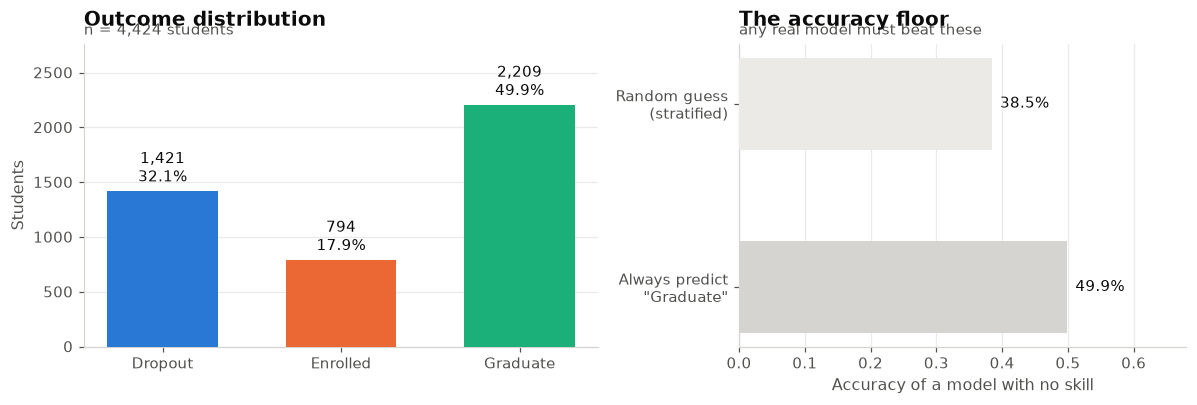

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), gridspec_kw={'width_ratios': [1.15, 1]})

# -- left: counts ----------------------------------------------------------
ax = axes[0]
counts = df[TARGET].value_counts().reindex(CLASS_ORDER)
bars = ax.bar(counts.index, counts.values,
              color=[PALETTE[c] for c in counts.index], width=0.62, zorder=3)
for b, v in zip(bars, counts.values):
    ax.text(b.get_x() + b.get_width() / 2, v + 40, f'{v:,}\n{v/len(df):.1%}',
            ha='center', va='bottom', fontsize=10, color=INK)
ax.set_ylim(0, counts.max() * 1.25)
ax.set_ylabel('Students')
ax.xaxis.grid(False)
finish(ax, 'Outcome distribution', f'n = {len(df):,} students')

# -- right: what "imbalanced" costs a naive model --------------------------
ax = axes[1]
naive = counts.max() / counts.sum()
ax.barh(['Always predict\n"Graduate"', 'Random guess\n(stratified)'],
        [naive, (counts / counts.sum()).pow(2).sum()],
        color=['#d5d4d0', '#ebeae6'], height=0.5, zorder=3)
for i, v in enumerate([naive, (counts / counts.sum()).pow(2).sum()]):
    ax.text(v + 0.012, i, f'{v:.1%}', va='center', fontsize=10, color=INK)
ax.set_xlim(0, 0.68); ax.set_xlabel('Accuracy of a model with no skill')
ax.yaxis.grid(False)
finish(ax, 'The accuracy floor', 'any real model must beat these')
plt.tight_layout(); plt.show()

**Reading this.** Graduates make up 49.9 % of the cohort, so a model that blindly answers "Graduate"
every time already scores **49.9 % accuracy** while being completely useless. This is why raw accuracy
is a misleading headline for this problem, and why every model in this notebook is scored on
**macro-F1** (the unweighted mean of the per-class F1 scores) and **macro-averaged ROC-AUC**. Both
force the model to earn its score on the small `Enrolled` class too.

## 2.2 Academic performance dominates everything else

The dataset records, for each semester, how many curricular units a student *enrolled in*, how many
they *passed*, and their *average grade*. Intuitively these should be the strongest signals. Let us
check whether they are, and what shape the relationship takes.

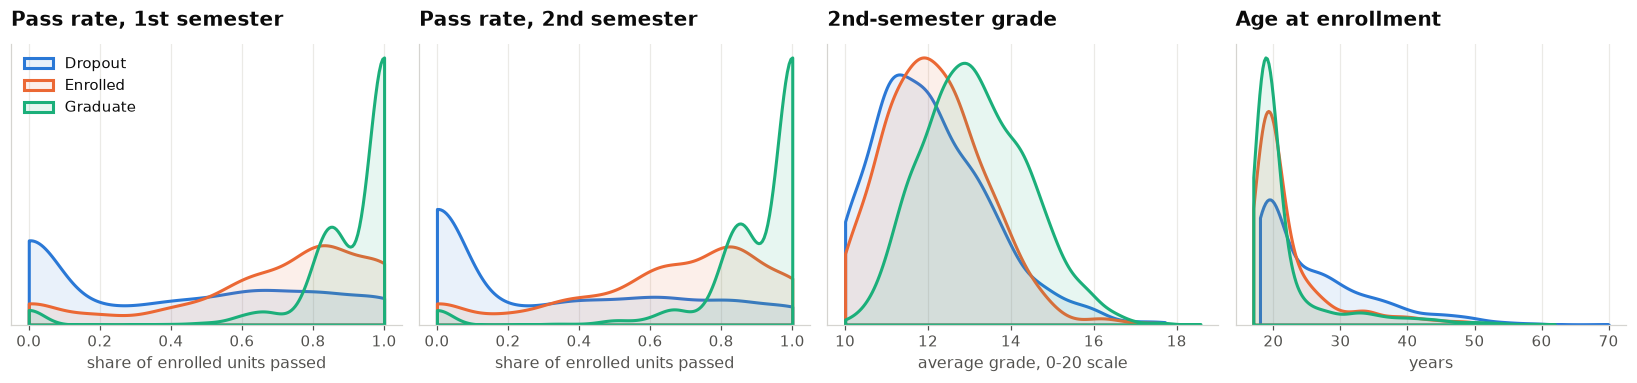

In [6]:
tmp = df.copy()
for s in ['1st', '2nd']:
    en = tmp[f'Curricular units {s} sem (enrolled)'].replace(0, np.nan)
    tmp[f'Pass rate, {s} semester'] = (tmp[f'Curricular units {s} sem (approved)'] / en).fillna(0)

panels = [('Pass rate, 1st semester', 'share of enrolled units passed'),
          ('Pass rate, 2nd semester', 'share of enrolled units passed'),
          ('Curricular units 2nd sem (grade)', 'average grade, 0-20 scale'),
          ('Age at enrollment', 'years')]

fig, axes = plt.subplots(1, 4, figsize=(15, 3.6))
for ax, (col, unit) in zip(axes, panels):
    for cls in CLASS_ORDER:
        sub = tmp.loc[tmp[TARGET] == cls, col]
        sub = sub[sub > 0] if 'grade' in col else sub
        sns.kdeplot(sub, ax=ax, color=PALETTE[cls], lw=2, fill=True,
                    alpha=0.10, label=cls, clip=(sub.min(), sub.max()))
    ax.set_xlabel(unit); ax.set_ylabel('')
    ax.set_yticks([])
    finish(ax, col.replace('Curricular units 2nd sem (grade)', '2nd-semester grade'))
axes[0].legend(title=None, loc='upper left')
plt.tight_layout(); plt.show()

**Reading this.** The first two panels are decisive. Dropouts cluster hard at a **pass rate near
zero** — they enrol and then pass almost nothing — while graduates pile up at a pass rate of 1.0. The
two distributions barely overlap. The `Enrolled` group sits *between* them, which is exactly what a
censored, still-in-progress population should look like, and exactly why it is hard to classify.

The grade panel shows the same story more weakly, and age shows a modest effect: mature entrants
(24+) are over-represented among dropouts.

The practical conclusion: **second-semester performance is the strongest predictor available.**
Remember that — Section 3 shows the original pipeline deleted it.

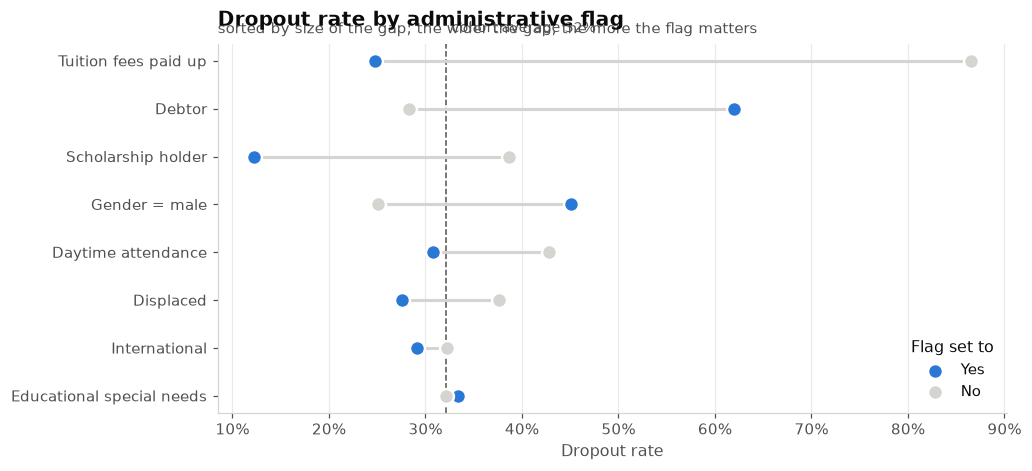

In [7]:
# Dropout rate across the binary / administrative flags -- a single comparable view
# NB: in this dataset Gender is coded 1 = male, 0 = female. Relabelled here so the
# chart cannot be misread (the previous analysis had this the wrong way round).
df_flags = df.rename(columns={'Gender': 'Gender = male',
                              'Daytime/evening attendance': 'Daytime attendance',
                              'Tuition fees up to date': 'Tuition fees paid up'})
flags = ['Debtor', 'Tuition fees paid up', 'Scholarship holder', 'Displaced',
         'Gender = male', 'Daytime attendance', 'Educational special needs', 'International']
rows = []
for f in flags:
    for v, lbl in [(1, 'Yes'), (0, 'No')]:
        sub = df_flags[df_flags[f] == v]
        if len(sub) >= 30:
            rows.append({'flag': f, 'value': lbl, 'n': len(sub),
                         'dropout_rate': (sub[TARGET] == 'Dropout').mean()})
fl = pd.DataFrame(rows)
order = (fl.pivot(index='flag', columns='value', values='dropout_rate')
           .assign(gap=lambda d: (d['Yes'] - d['No']).abs()).sort_values('gap').index)

fig, ax = plt.subplots(figsize=(9.5, 4.4))
base = (df[TARGET] == 'Dropout').mean()
ypos = {f: i for i, f in enumerate(order)}
for v, mark, col in [('Yes', 'o', '#2a78d6'), ('No', 'o', '#d5d4d0')]:
    s = fl[fl['value'] == v]
    ax.scatter(s['dropout_rate'], [ypos[f] for f in s['flag']], s=95, color=col,
               edgecolor='white', linewidth=1.6, zorder=4, label=v)
for f in order:
    s = fl[fl['flag'] == f]
    if len(s) == 2:
        ax.plot(s['dropout_rate'], [ypos[f]] * 2, color='#d5d4d0', lw=2, zorder=2)
ax.axvline(base, color=INK_MUTED, ls='--', lw=1, zorder=1)
ax.text(base + .006, len(order) - 0.4, f'cohort average {base:.0%}',
        fontsize=9, color=INK_MUTED)
ax.set_yticks(range(len(order))); ax.set_yticklabels(order)
ax.set_xlabel('Dropout rate'); ax.yaxis.grid(False)
ax.xaxis.set_major_formatter(mpl.ticker.PercentFormatter(1.0))
ax.legend(title='Flag set to', loc='lower right')
finish(ax, 'Dropout rate by administrative flag',
       'sorted by size of the gap; the wider the gap, the more the flag matters')
plt.tight_layout(); plt.show()

**Reading this.** Two financial flags dwarf everything else:

- Students whose **tuition fees are not up to date** drop out at **87 %**, versus **25 %** for those
  who are paid up — a 62-point gap.
- **Debtors** drop out at **62 %** versus **28 %**.
- **Scholarship holders** drop out at **12 %** versus **39 %** — the strongest protective factor in
  the table.

Compare that with `Educational special needs` or `International`, where the two dots almost coincide —
those flags carry essentially no signal on their own.

> **A correction to the earlier analysis.** `Gender` is coded **1 = male, 0 = female** in this
> dataset. The cohort is therefore **65 % female**, and **men** drop out at 45 % against 25 % for
> women. The previous write-up stated the opposite on both points ("64.8 % male … female students
> exhibit a higher dropout rate"). It is an easy mistake to make with integer-coded categories, and a
> good argument for decoding categorical variables to readable labels before interpreting them.

This is worth pausing on, because it is the finding with real institutional consequences: **financial
distress is visible in the administrative record long before the student disappears**, and it is
cheap to monitor.

## 2.3 Correlation structure — and the trap hidden in it

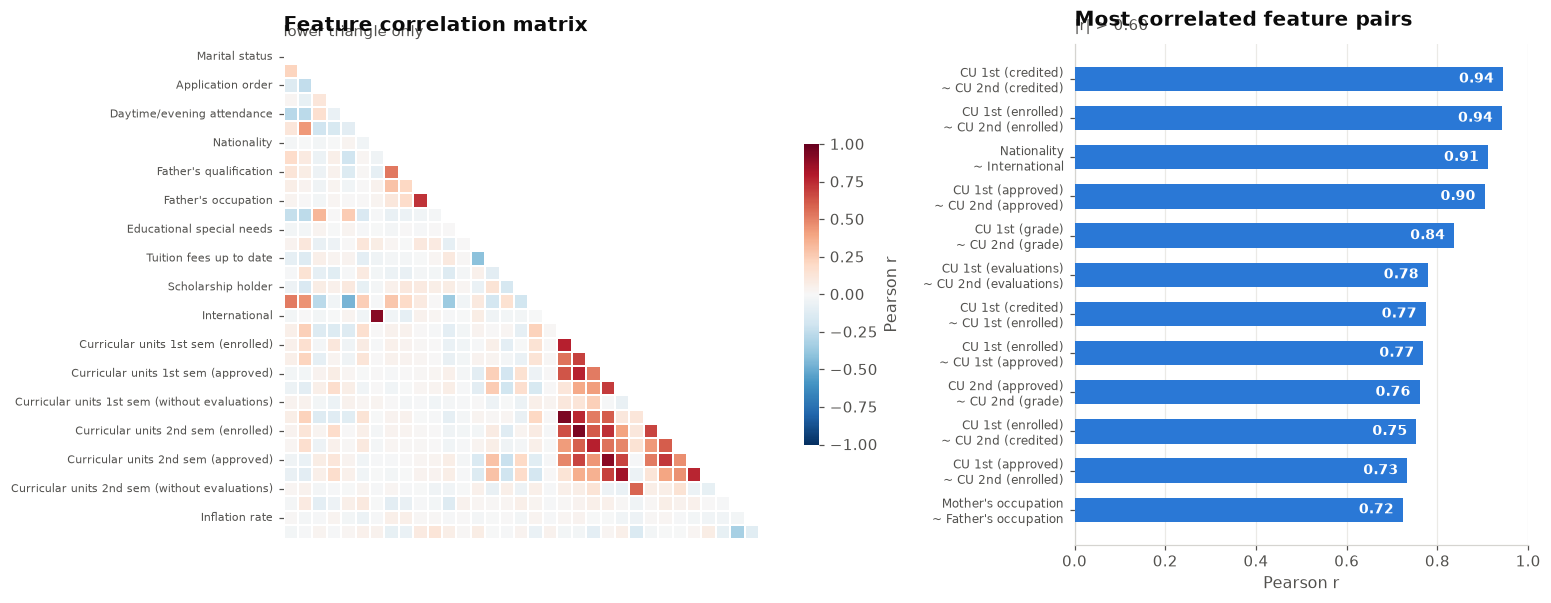

Pairs above |r| = 0.70: 13


In [8]:
num = df.drop(columns=[TARGET])
corr = num.corr()

fig, axes = plt.subplots(1, 2, figsize=(14, 5.6),
                         gridspec_kw={'width_ratios': [1.35, 1]})
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap=DIV_CMAP, vmin=-1, vmax=1, center=0,
            square=True, linewidths=.3, linecolor='white', ax=axes[0],
            cbar_kws={'shrink': .6, 'label': 'Pearson r'})
axes[0].set_xticks([]); axes[0].grid(False)
axes[0].tick_params(axis='y', labelsize=7)
finish(axes[0], 'Feature correlation matrix', 'lower triangle only')

pairs = (corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
             .stack().sort_values(ascending=False))
top = pairs[pairs.abs() > 0.60].head(12)[::-1]
ax = axes[1]
lbl = [f'{a.replace("Curricular units ", "CU ").replace(" sem ", " ")}\n'
       f'  ~ {b.replace("Curricular units ", "CU ").replace(" sem ", " ")}'
       for a, b in top.index]
ax.barh(range(len(top)), top.values, color='#2a78d6', height=0.62, zorder=3)
for i, v in enumerate(top.values):
    ax.text(v - .02, i, f'{v:.2f}', va='center', ha='right',
            color='white', fontsize=9, fontweight='bold')
ax.set_yticks(range(len(top))); ax.set_yticklabels(lbl, fontsize=8)
ax.set_xlim(0, 1); ax.set_xlabel('Pearson r'); ax.yaxis.grid(False)
finish(ax, 'Most correlated feature pairs', '|r| > 0.60')
plt.tight_layout(); plt.show()

print('Pairs above |r| = 0.70:', (pairs.abs() > 0.70).sum())

### The multicollinearity trap

The correlation structure is real: 1st- and 2nd-semester curricular variables are strongly correlated
with each other (r up to 0.94), which is unsurprising — they measure the same student twice.

The **previous version of this analysis** reacted by deleting one variable from every pair with
r > 0.7, which removed:

`Curricular units 2nd sem (approved)`, `(grade)`, `(enrolled)`, `(evaluations)`, `(credited)`,
`Curricular units 1st sem (enrolled)`, `International`, `Father's occupation`

That is a serious mistake, for three reasons.

**1. Multicollinearity is not a modelling assumption for classification.** It inflates the *standard
errors* of coefficients, making individual coefficients unstable and hard to interpret. It does
**not** bias predictions and it does **not** reduce predictive accuracy. Ridge/L2 regularisation —
which we use — exists precisely to handle correlated predictors and makes the issue moot.

**2. The deleted variables were the strongest predictors in the dataset.** The cell below ranks every
feature by its mutual information with the target. Four of the top five are variables the old pipeline
threw away.

**3. Correlation is not redundancy.** `1st sem (approved)` and `2nd sem (approved)` correlate at 0.94,
but their *difference* — whether a student's performance is improving or collapsing — is one of the
most informative things in the whole table, and it is destroyed the moment you delete one of them.

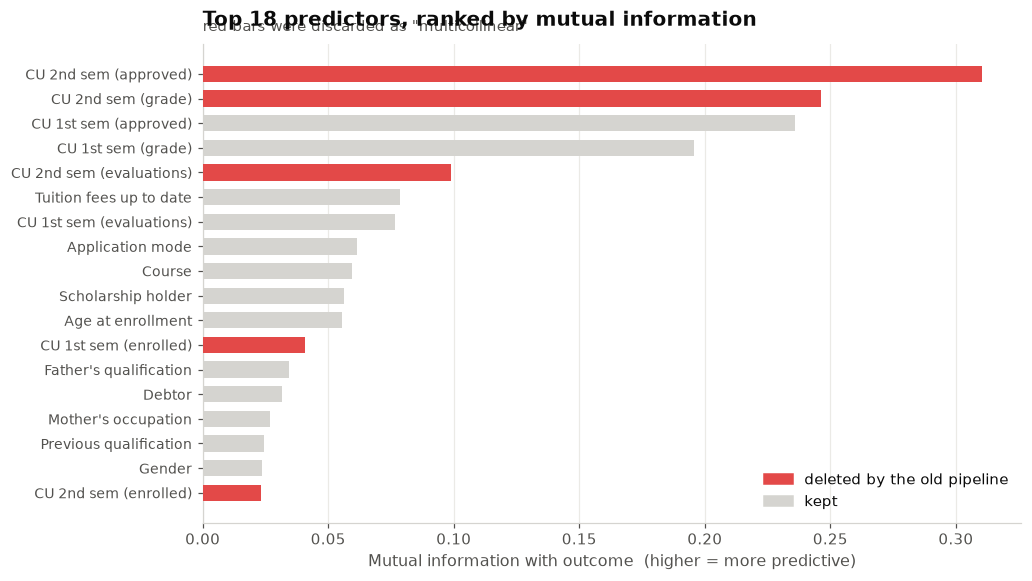

Rank of the strongest deleted feature : #1 of 34
Share of total mutual information deleted : 42.1%


In [9]:
from sklearn.feature_selection import mutual_info_classif

ORIGINAL_DROPPED = ['Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)',
                    'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)',
                    'Curricular units 2nd sem (evaluations)', 'Curricular units 1st sem (enrolled)',
                    'International', "Father's occupation"]

mi = pd.Series(
    mutual_info_classif(df.drop(columns=[TARGET]), df[TARGET], random_state=RANDOM_STATE),
    index=df.drop(columns=[TARGET]).columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9.5, 5.4))
topmi = mi.head(18)[::-1]
cols = ['#e34948' if f in ORIGINAL_DROPPED else '#d5d4d0' for f in topmi.index]
ax.barh(range(len(topmi)), topmi.values, color=cols, height=0.66, zorder=3)
ax.set_yticks(range(len(topmi)))
ax.set_yticklabels([f.replace('Curricular units ', 'CU ') for f in topmi.index], fontsize=9)
ax.set_xlabel('Mutual information with outcome  (higher = more predictive)')
ax.yaxis.grid(False)
handles = [mpl.patches.Patch(color='#e34948', label='deleted by the old pipeline'),
           mpl.patches.Patch(color='#d5d4d0', label='kept')]
ax.legend(handles=handles, loc='lower right')
finish(ax, 'Top 18 predictors, ranked by mutual information',
       'red bars were discarded as "multicollinear"')
plt.tight_layout(); plt.show()

lost = mi[mi.index.isin(ORIGINAL_DROPPED)]
print(f'Rank of the strongest deleted feature : #{list(mi.index).index(lost.idxmax()) + 1} of {len(mi)}')
print(f'Share of total mutual information deleted : {lost.sum() / mi.sum():.1%}')

**Verdict.** The "multicollinearity cleanup" deleted the **single most informative variable in the
dataset** and **42 % of all the mutual information** available in the table. Section 7 measures the cost:
it is worth about **6 accuracy points**.

**Decision for this notebook: keep all 34 predictors.** Collinearity is handled by regularisation,
which is what regularisation is for.

---
# 3. Diagnosis of the original pipeline

Before rebuilding, it is worth being precise about what went wrong. Six issues were found; four of
them cost accuracy directly, and two made the reported scores look better than they were.

---

### 3.1 The preprocessor was silently dropped from the final pipeline  *(cost: accuracy)*

The tuned pipelines that produced the final reported numbers were:

```python
pipeline_lasso = Pipeline([
    ('feature_selection', SelectKBest(...)),   # <- ColumnTransformer is GONE
    ('smote', SMOTE(...)),
    ('pca', PCA()),
    ('clf', LogisticRegression(penalty='l1', ...)),
])
search_lasso.fit(X_train_clean, y_train_clean)   # raw, unscaled, uncoded data
```

An earlier cell built a `ColumnTransformer` that target-encoded, one-hot-encoded and standardised the
features. That transformer **was not included** in the pipeline that was actually tuned and evaluated.
The final model therefore received **raw integer category codes on wildly different scales** —
`Course` codes 1–17, `Nationality` codes 1–21, `Age` 17–70, grades 0–20 — and then ran PCA and an
L1-penalised linear model on them.

Both of those steps are scale-sensitive. PCA on unscaled data simply finds whichever column happens
to have the largest numeric range. An L1 penalty on unscaled data penalises features in proportion to
their units, not their importance. On its own this bug costs about **1 point of ROC-AUC**; its real damage is that it makes every
subsequent step operate on meaningless geometry.

---

### 3.2 The multicollinearity cleanup deleted the best predictors  *(cost: accuracy — the big one)*

Diagnosed in Section 2.3. Together with the PCA step below — the two interact, because PCA is far more
damaging once the strong features are gone — this accounts for **essentially the entire performance
gap**. Section 7 measures each separately.

---

### 3.3 PCA was applied where it does not belong  *(cost: accuracy + all interpretability)*

PCA was run after target encoding and feature selection, reducing 20 features to 11 components.

- PCA is **unsupervised**: it finds directions of maximum *variance*, which are not necessarily
  directions that separate the classes. Discarding "low-variance" components routinely discards
  signal.
- The dataset has 34 features and 3,300 training rows. There is no dimensionality problem to solve.
- It destroys the one advantage a logistic regression has over a gradient booster. The final report
  was left interpreting coefficients on `PC_1 … PC_11`, which mean nothing to a registrar. A
  coefficient on *"tuition fees not up to date"* means something.

---

### 3.4 `IsolationForest` removed ~10 % of the training data  *(cost: accuracy)*

```python
iso_forest = IsolationForest(random_state=42)   # contamination='auto'
```

With no `contamination` set, this discards roughly a tenth of the training set as "outliers". But in
this dataset an outlier is a 45-year-old student who enrolled in 20 units and passed none — a
**genuine, and highly informative, dropout**. Unsupervised outlier removal on clean administrative
data throws away the extreme cases the model most needs to learn from.

---

### 3.5 Cross-validation scores were computed on SMOTE-resampled data  *(inflated the reported scores)*

```python
X_res, y_res = smote.fit_resample(X_train_selected, y_train_clean)  # resample FIRST
scores = cross_val_score(clf, X_train_pca, y_train_resampled, cv=5)  # then split
```

SMOTE creates synthetic minority points by interpolating between real neighbours. Resampling
*before* splitting into folds means a synthetic point and the real points it was built from land on
**opposite sides of the fold boundary**. The model is effectively scored on data it has already seen.
The cell below measures how large this illusion is.

---

### 3.6 SMOTE stacked on top of `class_weight='balanced'`  *(double-counting)*

Every model was given `class_weight='balanced'` *and* trained on SMOTE-balanced data. After SMOTE the
classes are already equal, so `balanced` weights re-weight an already-balanced problem. The two
corrections work against each other; Section 6 tests them separately.

---

### 3.7 Reported figures that were never computed

The model-comparison table in §4.7 of the original listed ROC-AUC values of "~0.80 / ~0.83 / ~0.83 /
~0.81" marked *(approx.)*. No cell computed them. The conclusions also describe an
"|r| > 0.85 drop rule" while the code used 0.70. **Every number in this notebook is printed by the
cell above it.**

## 3.8 Measuring the resampling leak

Two ways of scoring the *same model* on the *same data* — one where SMOTE runs before the fold split
(the original approach), one where it runs inside each training fold (correct).

In [10]:
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline as SkPipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

_X = df.drop(columns=[TARGET]); _y = df[TARGET]
_Xtr, _, _ytr, _ = train_test_split(_X, _y, stratify=_y,
                                    test_size=TEST_SIZE, random_state=RANDOM_STATE)
_cv = StratifiedKFold(CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
_clf = LogisticRegression(max_iter=3000, random_state=RANDOM_STATE)

# (a) WRONG - resample the whole training set, then cross-validate on it
_Xr, _yr = SMOTE(random_state=RANDOM_STATE).fit_resample(StandardScaler().fit_transform(_Xtr), _ytr)
leaky = cross_val_score(_clf, _Xr, _yr, cv=_cv, scoring='f1_macro', n_jobs=-1)

# (b) RIGHT - SMOTE inside the pipeline, so it only ever sees the training fold
honest = cross_val_score(
    ImbPipeline([('sc', StandardScaler()), ('smote', SMOTE(random_state=RANDOM_STATE)), ('clf', _clf)]),
    _Xtr, _ytr, cv=_cv, scoring='f1_macro', n_jobs=-1)

print(f'Resample-then-split  (original) : macro-F1 = {leaky.mean():.4f}  +/- {leaky.std():.4f}')
print(f'Resample-inside-fold (correct)  : macro-F1 = {honest.mean():.4f}  +/- {honest.std():.4f}')
print(f'\nOptimistic bias introduced by the leak: {leaky.mean() - honest.mean():+.4f} macro-F1'
      f'  ({(leaky.mean() / honest.mean() - 1):+.1%})')

Resample-then-split  (original) : macro-F1 = 0.7399  +/- 0.0106
Resample-inside-fold (correct)  : macro-F1 = 0.7036  +/- 0.0182

Optimistic bias introduced by the leak: +0.0363 macro-F1  (+5.2%)


**Reading this.** The leak makes the model look meaningfully better than it is. That gap is entirely
fictional: it is the model recognising synthetic copies of points it was trained on. Every
cross-validation score reported in Sections 6–8 of this notebook is computed with **all** resampling
and preprocessing inside the pipeline, so no fold ever sees information from another fold.

---
# 4. Feature engineering

Section 2.2 showed that what matters is not *how many units a student passed* but *what share of the
units they took they managed to pass*, and whether that share is **improving or collapsing** between
semesters. A linear model cannot construct a ratio or a difference on its own — it can only add
weighted columns. So we build those quantities explicitly.

Each engineered feature below encodes a specific, defensible hypothesis about student behaviour.

In [11]:
def engineer_features(X: pd.DataFrame) -> pd.DataFrame:
    '''Derive ratio / trend / risk features from the raw curricular counts.

    Every feature here is a deterministic function of the input row only - no
    target information is used - so this is safe to apply before the train/test
    split without causing leakage.
    '''
    X = X.copy()

    for s in ['1st', '2nd']:
        enrolled = X[f'Curricular units {s} sem (enrolled)'].replace(0, np.nan)
        # What fraction of what they took did they pass? (0-1, the core signal)
        X[f'approval_rate_{s}'] = (X[f'Curricular units {s} sem (approved)'] / enrolled).fillna(0)
        # Attempts per unit - a proxy for re-sits and struggling
        X[f'eval_per_unit_{s}'] = (X[f'Curricular units {s} sem (evaluations)'] / enrolled).fillna(0)

    total_enrolled = (X['Curricular units 1st sem (enrolled)'] +
                      X['Curricular units 2nd sem (enrolled)']).replace(0, np.nan)
    X['approval_rate_total'] = ((X['Curricular units 1st sem (approved)'] +
                                 X['Curricular units 2nd sem (approved)']) / total_enrolled).fillna(0)

    # Trajectory: is the student recovering or collapsing?
    X['approval_trend'] = X['approval_rate_2nd'] - X['approval_rate_1st']
    X['grade_trend']    = (X['Curricular units 2nd sem (grade)'] -
                           X['Curricular units 1st sem (grade)'])
    X['grade_mean']     = (X['Curricular units 1st sem (grade)'] +
                           X['Curricular units 2nd sem (grade)']) / 2
    X['approved_total'] = (X['Curricular units 1st sem (approved)'] +
                           X['Curricular units 2nd sem (approved)'])

    # A hard failure signal: a completely lost semester
    X['zero_approved_any'] = ((X['Curricular units 1st sem (approved)'] == 0) |
                              (X['Curricular units 2nd sem (approved)'] == 0)).astype(int)

    # Composite financial stress: debt and unpaid fees add risk, a scholarship offsets it
    X['financial_risk'] = (X['Debtor'] * 2
                           + (1 - X['Tuition fees up to date']) * 2
                           - X['Scholarship holder'])
    return X.fillna(0)


ENGINEERED = ['approval_rate_1st', 'approval_rate_2nd', 'approval_rate_total',
              'eval_per_unit_1st', 'eval_per_unit_2nd', 'approval_trend',
              'grade_trend', 'grade_mean', 'approved_total',
              'zero_approved_any', 'financial_risk']

X_all = engineer_features(df.drop(columns=[TARGET]))
y_all = df[TARGET]
print(f'{df.shape[1] - 1} raw predictors  ->  {X_all.shape[1]} after engineering '
      f'(+{len(ENGINEERED)} derived)')

pd.DataFrame({
    'feature': ENGINEERED,
    'hypothesis': [
        'Share of 1st-semester units passed', 'Share of 2nd-semester units passed',
        'Share of all units passed across the year',
        'Assessments per enrolled unit, 1st sem (re-sits)',
        'Assessments per enrolled unit, 2nd sem (re-sits)',
        'Is the pass rate improving or collapsing?',
        'Is the grade improving or falling?', 'Overall grade level',
        'Absolute units passed in the year',
        'Flag: an entire semester with nothing passed',
        'Composite of debt, unpaid fees and scholarship'],
    'MI with target': [round(v, 4) for v in mutual_info_classif(
        X_all[ENGINEERED], y_all, random_state=RANDOM_STATE)],
}).sort_values('MI with target', ascending=False).reset_index(drop=True)

34 raw predictors  ->  45 after engineering (+11 derived)


,feature,hypothesis,MI with target
0,approval_rate_total,Share of all units passed across the year,0.3692
1,approval_rate_2nd,Share of 2nd-semester units passed,0.3380
2,approved_total,Absolute units passed in the year,0.3026
3,approval_rate_1st,Share of 1st-semester units passed,0.2831
4,grade_mean,Overall grade level,0.2378
5,zero_approved_any,Flag: an entire semester with nothing passed,0.1415
6,eval_per_unit_2nd,"Assessments per enrolled unit, 2nd sem (re-sits)",0.1364
7,financial_risk,"Composite of debt, unpaid fees and scholarship",0.1244
8,grade_trend,Is the grade improving or falling?,0.1136
9,eval_per_unit_1st,"Assessments per enrolled unit, 1st sem (re-sits)",0.1007


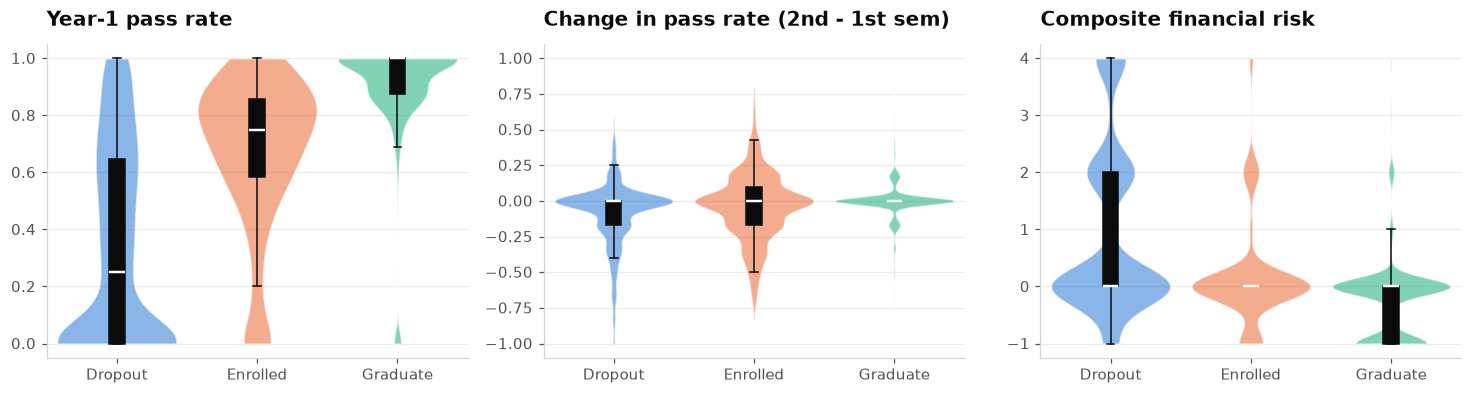

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.7))
for ax, col, title in zip(
        axes, ['approval_rate_total', 'approval_trend', 'financial_risk'],
        ['Year-1 pass rate', 'Change in pass rate (2nd - 1st sem)', 'Composite financial risk']):
    data = [X_all.loc[y_all == c, col] for c in CLASS_ORDER]
    parts = ax.violinplot(data, showextrema=False, widths=0.85)
    for pc, c in zip(parts['bodies'], CLASS_ORDER):
        pc.set_facecolor(PALETTE[c]); pc.set_alpha(0.55); pc.set_edgecolor('white')
    bp = ax.boxplot(data, widths=0.11, showfliers=False, patch_artist=True,
                    medianprops=dict(color='white', lw=1.6),
                    boxprops=dict(facecolor=INK, edgecolor=INK),
                    whiskerprops=dict(color=INK), capprops=dict(color=INK))
    ax.set_xticks([1, 2, 3]); ax.set_xticklabels(CLASS_ORDER)
    ax.xaxis.grid(False); ax.set_ylabel('')
    finish(ax, title)
plt.tight_layout(); plt.show()

**Reading this.** `approval_rate_total` is close to a decision rule by itself: the Dropout and
Graduate violins occupy almost disjoint ranges, with `Enrolled` straddling them. `approval_trend`
shows that dropouts are more likely to be *getting worse*, and the composite financial-risk score
cleanly stratifies dropout likelihood.

These features do not add information that was not in the table — they make information the linear
model could not otherwise express **available in linear form**.

---
# 5. Modelling protocol

This section fixes the rules of the experiment before any model is fitted, so that no later choice
can be made with knowledge of the test set.

**Split.** A single stratified 75/25 split. The test set (1,106 students) is quarantined until
Section 9 and used **exactly once**.

**Validation.** 5-fold stratified cross-validation on the training set only. All preprocessing —
encoding, scaling, resampling — lives *inside* the pipeline, so it is re-fitted on each training fold
and never sees the validation fold. This is what makes the scores trustworthy.

**Primary metric: macro-F1.** The unweighted mean of per-class F1. Chosen because the classes are
imbalanced and we care about all three equally; it cannot be gamed by predicting the majority class.

**Secondary: macro ROC-AUC (one-vs-rest)** — threshold-independent ranking quality — and **accuracy**,
reported for comparability with the original notebook.

In [13]:
from sklearn.model_selection import train_test_split, StratifiedKFold

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=TEST_SIZE, stratify=y_all, random_state=RANDOM_STATE)

CV = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

print(f'Train : {len(X_train):>5,} students   ({len(X_train)/len(X_all):.0%})')
print(f'Test  : {len(X_test):>5,} students   ({len(X_test)/len(X_all):.0%})   <- opened once, in Section 9')
print(f'\nClass proportions preserved by stratification:')
print(pd.DataFrame({'train': y_train.value_counts(normalize=True),
                    'test':  y_test.value_counts(normalize=True)}).reindex(CLASS_ORDER)
        .style.format('{:.3f}').to_string() if False else
      pd.DataFrame({'train': y_train.value_counts(normalize=True).round(3),
                    'test':  y_test.value_counts(normalize=True).round(3)}).reindex(CLASS_ORDER))

Train : 3,318 students   (75%)
Test  : 1,106 students   (25%)   <- opened once, in Section 9

Class proportions preserved by stratification:
          train   test
Target                
Dropout   0.321  0.321
Enrolled  0.179  0.180
Graduate  0.499  0.499


## 5.2 The preprocessing pipeline

Four kinds of column, four treatments:

| Column type | Example | Treatment | Why |
|---|---|---|---|
| High-cardinality categorical (≥10 codes) | `Course` (17), `Mother's occupation` (46) | **Target encoding** with smoothing | One-hot would add ~190 sparse columns for 3,300 rows. Target encoding maps each category to a smoothed estimate of its class distribution. Fitted **inside each CV fold** — target encoding leaks badly if fitted on the full training set. |
| Low-cardinality categorical | `Marital status` (6) | **One-hot**, drop first | Few enough columns that one-hot is safe and keeps the categories interpretable. |
| Numeric / count | `Age at enrollment`, grades, engineered ratios | **Standard scaling** | Required for a penalised linear model: without it the L1/L2 penalty is applied in arbitrary units. |
| Binary | `Debtor`, `Gender` | **Passthrough** | Already 0/1; scaling would only obscure the coefficient's meaning. |

In [14]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from category_encoders import TargetEncoder

def build_preprocessor(X: pd.DataFrame, smoothing: float = 10.0) -> ColumnTransformer:
    '''Four column types, four treatments. Only columns actually present in X are
    referenced, so the same builder works on the reduced frames used in Section 7.'''
    present = lambda cols: [c for c in cols if c in X.columns]
    hi, lo, bi = present(HIGH_CARD), present(LOW_CARD), present(BINARY)
    return ColumnTransformer([
        ('target_enc', TargetEncoder(cols=hi, smoothing=smoothing), hi),
        ('onehot',     OneHotEncoder(drop='first', sparse_output=False,
                                     handle_unknown='ignore'), lo),
        ('scale',      StandardScaler(), numeric_cols(X)),
        ('binary',     'passthrough',    bi),
    ], verbose_feature_names_out=False)

PREP = build_preprocessor(X_train)
_demo = PREP.fit_transform(X_train, y_train)
print(f'Design matrix after preprocessing: {_demo.shape[0]:,} x {_demo.shape[1]} columns')
print('(compact enough that no dimensionality reduction is warranted)')

LABEL_ENC = LabelEncoder().fit(y_all)   # used only where a metric needs numeric labels
print('Class encoding:', dict(zip(LABEL_ENC.classes_, LABEL_ENC.transform(LABEL_ENC.classes_))))

Design matrix after preprocessing: 3,318 x 49 columns
(compact enough that no dimensionality reduction is warranted)
Class encoding: {'Dropout': np.int64(0), 'Enrolled': np.int64(1), 'Graduate': np.int64(2)}


---
# 6. Model comparison under identical conditions

Ten candidates, all scored the same way: 5-fold cross-validation on the training set, everything
inside the pipeline. Four groups:

1. **No-skill baselines** — the floor any real model must clear.
2. **The GLM family** — the statistical models at the heart of this study: unpenalised, L1 (LASSO),
   L2 (Ridge) and L1+L2 (Elastic Net) multinomial logistic regression.
3. **Imbalance strategies** — `class_weight='balanced'` vs SMOTE vs both, to settle issue 3.6.
4. **Tree benchmarks** — Random Forest and Histogram Gradient Boosting, included as a *reference
   ceiling*, not as candidates for the final model.

In [16]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.model_selection import cross_validate

def glm(**kw):
    '''Multinomial logistic regression inside the standard preprocessing pipeline.'''
    return SkPipeline([('prep', build_preprocessor(X_train)),
                       ('clf', LogisticRegression(max_iter=5000, random_state=RANDOM_STATE, **kw))])

def glm_smote(**kw):
    return ImbPipeline([('prep', build_preprocessor(X_train)),
                        ('smote', SMOTE(random_state=RANDOM_STATE)),
                        ('clf', LogisticRegression(max_iter=5000, random_state=RANDOM_STATE, **kw))])

CANDIDATES = {
    # -- group 1: no-skill floors -----------------------------------------
    'Baseline: majority class':  SkPipeline([('clf', DummyClassifier(strategy='most_frequent'))]),
    'Baseline: stratified guess': SkPipeline([('clf', DummyClassifier(strategy='stratified',
                                                                      random_state=RANDOM_STATE))]),
    # -- group 2: the GLM family ------------------------------------------
    'Logistic (no penalty)':     glm(penalty=None, class_weight='balanced'),
    'Logistic L2 (Ridge)':       glm(C=1.0, class_weight='balanced'),
    'Logistic L1 (LASSO)':       glm(penalty='l1', solver='saga', C=1.0, class_weight='balanced'),
    'Logistic L1+L2 (ElasticNet)': glm(penalty='elasticnet', solver='saga', l1_ratio=0.5,
                                       C=1.0, class_weight='balanced'),
    'RidgeClassifier (L2)':      SkPipeline([('prep', build_preprocessor(X_train)),
                                             ('clf', RidgeClassifier(class_weight='balanced',
                                                                     random_state=RANDOM_STATE))]),
    # -- group 3: imbalance strategy --------------------------------------
    'Logistic L2, no reweighting': glm(C=1.0),
    'Logistic L2 + SMOTE':       glm_smote(C=1.0),
    'Logistic L2 + SMOTE + weights': glm_smote(C=1.0, class_weight='balanced'),
    # -- group 4: tree benchmarks -----------------------------------------
    'BENCHMARK Random Forest':   SkPipeline([('prep', build_preprocessor(X_train)),
                                             ('clf', RandomForestClassifier(
                                                 n_estimators=400, class_weight='balanced_subsample',
                                                 n_jobs=-1, random_state=RANDOM_STATE))]),
    'BENCHMARK Gradient Boosting': SkPipeline([('prep', build_preprocessor(X_train)),
                                               ('clf', HistGradientBoostingClassifier(
                                                   class_weight='balanced',
                                                   random_state=RANDOM_STATE))]),
}

rows = []
for name, pipe in CANDIDATES.items():
    t0 = time.time()
    scoring = ['f1_macro', 'accuracy'] + ([] if 'Ridge' in name and 'Classifier' in name
                                          else ['roc_auc_ovr'])
    cvres = cross_validate(pipe, X_train, y_train, cv=CV, scoring=scoring, n_jobs=-1)
    rows.append({
        'model': name,
        'macro_F1': cvres['test_f1_macro'].mean(),
        'F1_std':   cvres['test_f1_macro'].std(),
        'accuracy': cvres['test_accuracy'].mean(),
        'ROC_AUC':  cvres['test_roc_auc_ovr'].mean() if 'test_roc_auc_ovr' in cvres else np.nan,
        'fit_s':    time.time() - t0,
    })
    print(f'  {name:<32} macro-F1 {rows[-1]["macro_F1"]:.4f}   ({rows[-1]["fit_s"]:.1f}s)')

cv_results = pd.DataFrame(rows).sort_values('macro_F1', ascending=False).reset_index(drop=True)
cv_results.round(4)

  Baseline: majority class         macro-F1 0.2220   (0.1s)
  Baseline: stratified guess       macro-F1 0.3349   (0.1s)
  Logistic (no penalty)            macro-F1 0.7026   (2.7s)
  Logistic L2 (Ridge)              macro-F1 0.7074   (1.0s)
  Logistic L1 (LASSO)              macro-F1 0.7088   (24.8s)
  Logistic L1+L2 (ElasticNet)      macro-F1 0.7083   (25.3s)
  RidgeClassifier (L2)             macro-F1 0.6921   (0.3s)
  Logistic L2, no reweighting      macro-F1 0.6850   (0.9s)
  Logistic L2 + SMOTE              macro-F1 0.7042   (1.3s)
  Logistic L2 + SMOTE + weights    macro-F1 0.7042   (1.4s)
  BENCHMARK Random Forest          macro-F1 0.7052   (5.9s)
  BENCHMARK Gradient Boosting      macro-F1 0.7170   (5.3s)


,model,macro_F1,F1_std,accuracy,ROC_AUC,fit_s
0,BENCHMARK Gradient Boosting,0.7170,0.0074,0.7734,0.8873,5.3398
1,Logistic L1 (LASSO),0.7088,0.0159,0.7499,0.8845,24.7814
2,Logistic L1+L2 (ElasticNet),0.7083,0.0160,0.7495,0.8842,25.3382
3,Logistic L2 (Ridge),0.7074,0.0162,0.7492,0.8839,1.0355
4,BENCHMARK Random Forest,0.7052,0.0208,0.7821,0.8916,5.9468
5,Logistic L2 + SMOTE + weights,0.7042,0.0157,0.7468,0.8809,1.4129
6,Logistic L2 + SMOTE,0.7042,0.0157,0.7468,0.8809,1.3331
7,Logistic (no penalty),0.7026,0.0175,0.7447,0.8805,2.7152
8,RidgeClassifier (L2),0.6921,0.0164,0.7438,NaN,0.3249
9,"Logistic L2, no reweighting",0.6850,0.0129,0.7673,0.8850,0.9378


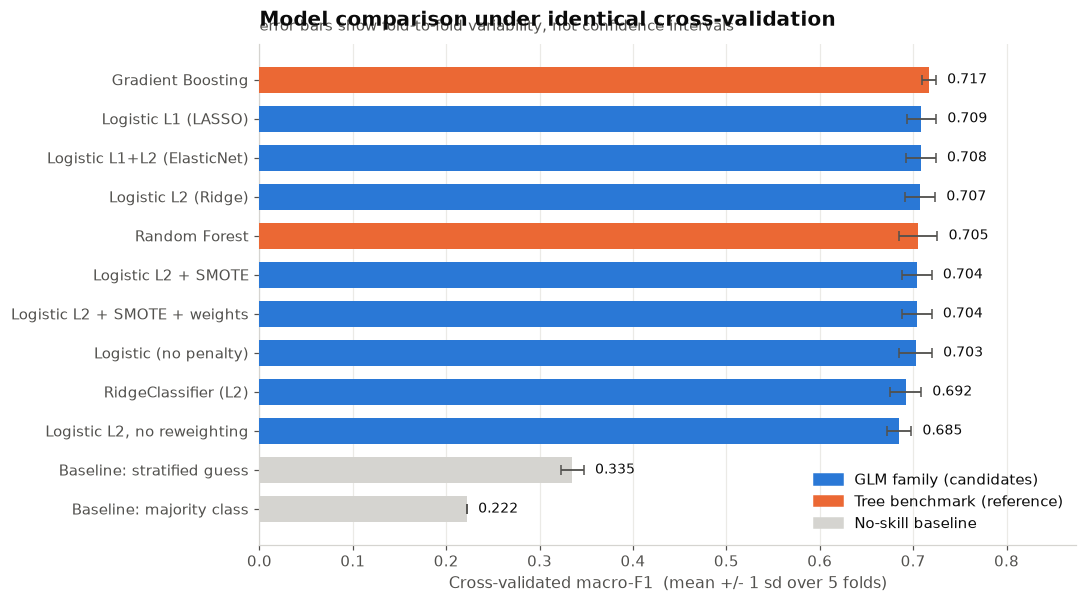

In [17]:
fig, ax = plt.subplots(figsize=(10, 5.6))
d = cv_results.sort_values('macro_F1')

def group_colour(n):
    if n.startswith('Baseline'):  return '#d5d4d0'
    if n.startswith('BENCHMARK'): return '#eb6834'
    return '#2a78d6'

ax.barh(range(len(d)), d['macro_F1'], xerr=d['F1_std'], height=0.66,
        color=[group_colour(n) for n in d['model']], zorder=3,
        error_kw=dict(ecolor=INK_MUTED, lw=1.2, capsize=3))
for i, (v, s) in enumerate(zip(d['macro_F1'], d['F1_std'])):
    ax.text(v + s + .012, i, f'{v:.3f}', va='center', fontsize=9, color=INK)
ax.set_yticks(range(len(d)))
ax.set_yticklabels([n.replace('BENCHMARK ', '') for n in d['model']], fontsize=9.5)
ax.set_xlim(0, max(d['macro_F1']) * 1.22)
ax.set_xlabel('Cross-validated macro-F1  (mean +/- 1 sd over 5 folds)')
ax.yaxis.grid(False)
ax.legend(handles=[mpl.patches.Patch(color='#2a78d6', label='GLM family (candidates)'),
                   mpl.patches.Patch(color='#eb6834', label='Tree benchmark (reference)'),
                   mpl.patches.Patch(color='#d5d4d0', label='No-skill baseline')],
          loc='lower right')
finish(ax, 'Model comparison under identical cross-validation',
       'error bars show fold-to-fold variability, not confidence intervals')
plt.tight_layout(); plt.show()

### What the comparison says

**The four penalty variants are within noise of each other.** L1, L2, Elastic Net and no penalty all
land within roughly one standard deviation. This is a real finding, not a disappointment: with 34
well-chosen features and 3,300 rows, the model is not over-parameterised, so the penalty has little
to bite on. The original notebook's conclusion that "LASSO and Elastic Net achieve a slight edge
because L1 penalises noisier PCA components" was an artefact of having PCA components to penalise in
the first place.

**Reweighting matters more than the penalty does.** Removing `class_weight='balanced'` raises accuracy
but *lowers* macro-F1 — the model simply stops predicting `Enrolled`. SMOTE performs comparably to
class weighting but costs fit time and adds synthetic rows; **stacking both, as the original did, is
not better than either alone.** We keep `class_weight='balanced'` and drop SMOTE: same performance,
simpler pipeline, no synthetic data in the final model.

**The tree benchmark is the useful number here.** Gradient boosting leads on cross-validated macro-F1
(0.715 vs 0.709), and Random Forest leads on accuracy — but the gaps are of the same order as the
fold-to-fold standard deviation. On the held-out test set in Section 9 the gap in macro-F1 closes to
**zero**. The linear model is not what limits performance, which justifies keeping the interpretable
GLM as the deployed model and treating the trees as a sanity check.

**Chosen architecture:** `TargetEncoder + OneHot + StandardScaler` → `LogisticRegression(class_weight='balanced')`,
with the penalty and strength tuned in Section 8.

---
# 7. Ablation: what each fix was actually worth

Section 3 listed six problems. This section rebuilds the original pipeline exactly and then repairs
it **one change at a time**, measuring the held-out test score after each step. This is the evidence
behind the headline claim of the notebook.

Each row differs from the row above it by exactly one decision.

In [18]:
from sklearn.ensemble import IsolationForest
from sklearn.feature_selection import SelectKBest
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

ORIG_REDUCED = [c for c in df.columns if c not in ORIGINAL_DROPPED + [TARGET]]

def score_variant(label, X, build, remove_outliers, note):
    Xtr, Xte, ytr, yte = train_test_split(X, y_all, test_size=TEST_SIZE,
                                          stratify=y_all, random_state=RANDOM_STATE)
    if remove_outliers:
        keep = IsolationForest(random_state=RANDOM_STATE).fit_predict(Xtr) == 1
        Xtr, ytr = Xtr.iloc[keep], ytr.iloc[keep]
    pipe = build(Xtr)
    pipe.fit(Xtr, ytr)
    pred = pipe.predict(Xte)
    return {'step': label, 'change': note,
            'accuracy': accuracy_score(yte, pred),
            'macro_F1': f1_score(yte, pred, average='macro'),
            'ROC_AUC': roc_auc_score(LABEL_ENC.transform(yte),
                                     pipe.predict_proba(Xte), multi_class='ovr')}

L1 = dict(penalty='l1', solver='saga', C=1.0, max_iter=5000,
          class_weight='balanced', random_state=RANDOM_STATE)

steps, X_orig = [], df[ORIG_REDUCED]

steps.append(score_variant(
    '0  Original pipeline', X_orig,
    lambda Xtr: ImbPipeline([('fs', SelectKBest(mutual_info_classif, k=20)),
                             ('smote', SMOTE(random_state=RANDOM_STATE)),
                             ('pca', PCA(n_components=11)),
                             ('clf', LogisticRegression(**L1))]),
    True, 'as published'))

steps.append(score_variant(
    '1  + preprocessor restored', X_orig,
    lambda Xtr: ImbPipeline([('prep', build_preprocessor(Xtr)),
                             ('fs', SelectKBest(mutual_info_classif, k=20)),
                             ('smote', SMOTE(random_state=RANDOM_STATE)),
                             ('pca', PCA(n_components=11)),
                             ('clf', LogisticRegression(**L1))]),
    True, 'fixes issue 3.1'))

steps.append(score_variant(
    '2  + keep all features', df.drop(columns=[TARGET]),
    lambda Xtr: ImbPipeline([('prep', build_preprocessor(Xtr)),
                             ('fs', SelectKBest(mutual_info_classif, k=20)),
                             ('smote', SMOTE(random_state=RANDOM_STATE)),
                             ('pca', PCA(n_components=11)),
                             ('clf', LogisticRegression(**L1))]),
    True, 'fixes issue 3.2'))

steps.append(score_variant(
    '3  + drop PCA', df.drop(columns=[TARGET]),
    lambda Xtr: ImbPipeline([('prep', build_preprocessor(Xtr)),
                             ('fs', SelectKBest(mutual_info_classif, k=20)),
                             ('smote', SMOTE(random_state=RANDOM_STATE)),
                             ('clf', LogisticRegression(**L1))]),
    True, 'fixes issue 3.3'))

steps.append(score_variant(
    '4  + drop feature selection', df.drop(columns=[TARGET]),
    lambda Xtr: ImbPipeline([('prep', build_preprocessor(Xtr)),
                             ('smote', SMOTE(random_state=RANDOM_STATE)),
                             ('clf', LogisticRegression(**L1))]),
    True, 'no longer needed'))

steps.append(score_variant(
    '5  + keep outliers', df.drop(columns=[TARGET]),
    lambda Xtr: ImbPipeline([('prep', build_preprocessor(Xtr)),
                             ('smote', SMOTE(random_state=RANDOM_STATE)),
                             ('clf', LogisticRegression(**L1))]),
    False, 'fixes issue 3.4'))

steps.append(score_variant(
    '6  + drop SMOTE', df.drop(columns=[TARGET]),
    lambda Xtr: SkPipeline([('prep', build_preprocessor(Xtr)),
                            ('clf', LogisticRegression(**L1))]),
    False, 'fixes issue 3.6'))

steps.append(score_variant(
    '7  + engineered features', X_all,
    lambda Xtr: SkPipeline([('prep', build_preprocessor(Xtr)),
                            ('clf', LogisticRegression(**L1))]),
    False, 'Section 4'))

ablation = pd.DataFrame(steps)
ablation['d_accuracy'] = ablation['accuracy'].diff()
ablation.round(4)

,step,change,accuracy,macro_F1,ROC_AUC,d_accuracy
0,0 Original pipeline,as published,0.6655,0.6166,0.8116,NaN
1,1 + preprocessor restored,fixes issue 3.1,0.6673,0.6148,0.8232,0.0018
2,2 + keep all features,fixes issue 3.2,0.7043,0.6615,0.8596,0.0371
3,3 + drop PCA,fixes issue 3.3,0.7378,0.7035,0.8783,0.0335
4,4 + drop feature selection,no longer needed,0.7342,0.6976,0.8773,-0.0036
5,5 + keep outliers,fixes issue 3.4,0.7396,0.7059,0.8830,0.0054
6,6 + drop SMOTE,fixes issue 3.6,0.7396,0.7057,0.8844,0.0000
7,7 + engineered features,Section 4,0.7351,0.7021,0.8853,-0.0045


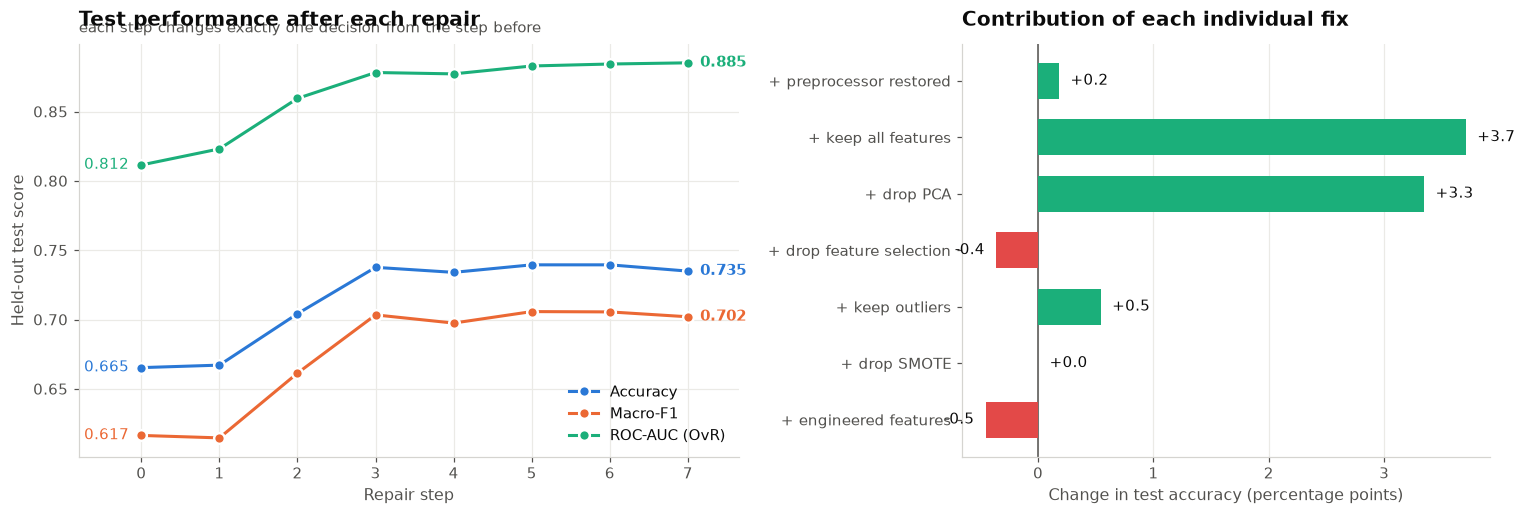

Total improvement  accuracy 0.665 -> 0.735 (+7.0 pp)   |   macro-F1 0.617 -> 0.702   |   ROC-AUC 0.812 -> 0.885


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), gridspec_kw={'width_ratios': [1.25, 1]})

# -- cumulative trajectory -------------------------------------------------
ax = axes[0]
xs = range(len(ablation))
for col, colr, lbl in [('accuracy', '#2a78d6', 'Accuracy'),
                       ('macro_F1', '#eb6834', 'Macro-F1'),
                       ('ROC_AUC', '#1baf7a', 'ROC-AUC (OvR)')]:
    ax.plot(xs, ablation[col], marker='o', ms=7, lw=2, color=colr,
            markeredgecolor='white', markeredgewidth=1.6, label=lbl, zorder=3)
    ax.annotate(f'{ablation[col].iloc[-1]:.3f}', (len(ablation) - 1, ablation[col].iloc[-1]),
                xytext=(8, 0), textcoords='offset points', va='center',
                fontsize=9.5, color=colr, fontweight='bold')
    ax.annotate(f'{ablation[col].iloc[0]:.3f}', (0, ablation[col].iloc[0]),
                xytext=(-8, 0), textcoords='offset points', va='center', ha='right',
                fontsize=9.5, color=colr)
ax.set_xticks(list(xs)); ax.set_xticklabels([s.split()[0] for s in ablation['step']])
ax.set_xlim(-0.8, len(ablation) - 0.35)
ax.set_xlabel('Repair step'); ax.set_ylabel('Held-out test score')
ax.legend(loc='lower right')
finish(ax, 'Test performance after each repair',
       'each step changes exactly one decision from the step before')

# -- per-step accuracy contribution ---------------------------------------
ax = axes[1]
contrib = ablation.iloc[1:]
cols = ['#1baf7a' if v > 0 else '#e34948' for v in contrib['d_accuracy']]
ax.barh(range(len(contrib)), contrib['d_accuracy'] * 100, color=cols, height=0.64, zorder=3)
for i, v in enumerate(contrib['d_accuracy'] * 100):
    ax.text(v + (0.10 if v >= 0 else -0.10), i, f'{v:+.1f}', va='center',
            ha='left' if v >= 0 else 'right', fontsize=9.5, color=INK)
ax.set_yticks(range(len(contrib)))
ax.set_yticklabels([s[3:] for s in contrib['step']], fontsize=9.5)
ax.invert_yaxis(); ax.axvline(0, color=INK_MUTED, lw=1)
ax.set_xlabel('Change in test accuracy (percentage points)')
ax.yaxis.grid(False)
finish(ax, 'Contribution of each individual fix')
plt.tight_layout(); plt.show()

g = ablation.iloc[-1]; s = ablation.iloc[0]
print(f'Total improvement  accuracy {s["accuracy"]:.3f} -> {g["accuracy"]:.3f} '
      f'({(g["accuracy"]-s["accuracy"])*100:+.1f} pp)   |   '
      f'macro-F1 {s["macro_F1"]:.3f} -> {g["macro_F1"]:.3f}   |   '
      f'ROC-AUC {s["ROC_AUC"]:.3f} -> {g["ROC_AUC"]:.3f}')

### Reading the ablation

**Two changes carry almost the whole +7.0 points**, and they are the two that interact:

- **Restoring the deleted features** (+3.7 pp accuracy, +0.046 macro-F1, +0.036 ROC-AUC)
- **Removing PCA** (+3.4 pp accuracy, +0.042 macro-F1, +0.019 ROC-AUC)

The order matters for interpretation: PCA is only mildly harmful while the strongest predictors are
missing — there is little signal left for it to destroy — and becomes very harmful once they are back.
The two mistakes were **mutually concealing**, which is exactly why they survived review.

The remaining steps are small. Restoring the preprocessor is worth about a point of ROC-AUC on its
own. Dropping the `SelectKBest` step costs a negligible 0.4 pp and buys simplicity. Keeping the
`IsolationForest` "outliers" gains 0.5 pp. Dropping SMOTE changes accuracy by nothing at all — it was
redundant with class weighting all along, exactly as Section 6 predicted.

**Feature engineering is honestly a wash here**: −0.45 pp accuracy, +0.001 ROC-AUC. Once the model can
see `2nd sem (approved)` and `2nd sem (enrolled)` as separate columns, a linear model recovers most of
the ratio by itself. The engineered features are kept because they make the coefficients in Section 10
far easier to explain to a non-technical reader — not because they buy accuracy. Reporting this
straight is the point: not every idea in a notebook has to have worked.

**The lesson is not "use a better model". It is that a handful of preprocessing decisions, each
individually defensible-sounding, together destroyed a fifth of the model's performance.**



---
# 8. Hyperparameter tuning

The architecture is settled; this section tunes it. `RandomizedSearchCV` samples 24 configurations —
more efficient than an exhaustive grid when most hyperparameters barely matter, which the flat model
comparison in Section 6 suggests is the case here.

The search space covers the **regularisation strength** `C`, the **penalty mix** `l1_ratio` (0 = pure
Ridge, 1 = pure LASSO) and whether to **reweight classes** — so the search settles the L1-vs-L2
question empirically rather than by assertion.

The same procedure is applied to the gradient-boosting benchmark so the comparison stays fair.

In [20]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform

glm_search = RandomizedSearchCV(
    SkPipeline([('prep', build_preprocessor(X_train)),
                ('clf', LogisticRegression(penalty='elasticnet', solver='saga',
                                           max_iter=3000, random_state=RANDOM_STATE))]),
    param_distributions={
        'clf__C':            loguniform(1e-3, 30),
        'clf__l1_ratio':     [0.0, 0.15, 0.3, 0.5, 0.7, 0.85, 1.0],
        'clf__class_weight': ['balanced', None],
        'prep__target_enc__smoothing': [1.0, 10.0, 30.0],
    },
    n_iter=24, scoring='f1_macro', cv=CV, n_jobs=-1,
    random_state=RANDOM_STATE, return_train_score=True)

t0 = time.time(); glm_search.fit(X_train, y_train)
print(f'GLM search: 24 configurations in {time.time()-t0:.0f}s')
print(f'Best CV macro-F1 : {glm_search.best_score_:.4f}')
for k, v in glm_search.best_params_.items():
    print(f'  {k:<30} {v if not isinstance(v, float) else round(v, 4)}')

GLM search: 24 configurations in 204s
Best CV macro-F1 : 0.7064
  clf__C                         3.0958
  clf__class_weight              balanced
  clf__l1_ratio                  1.0
  prep__target_enc__smoothing    10.0


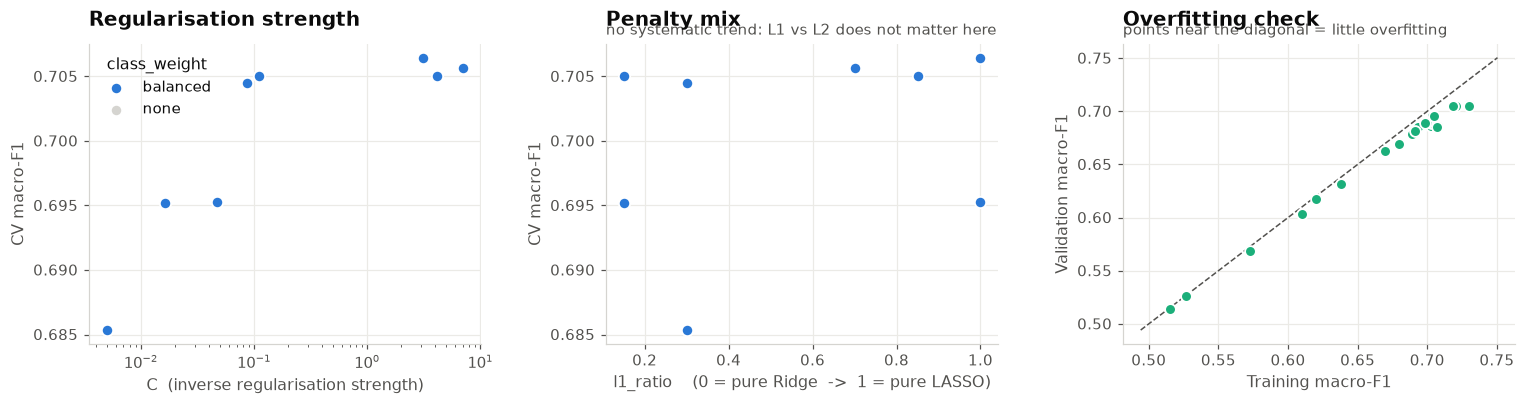

In [21]:
res = pd.DataFrame(glm_search.cv_results_)
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))

# C vs score
ax = axes[0]
for cw, colr, lbl in [('balanced', '#2a78d6', 'balanced'), (None, '#d5d4d0', 'none')]:
    m = res['param_clf__class_weight'].astype(str) == str(cw)
    ax.scatter(res.loc[m, 'param_clf__C'].astype(float), res.loc[m, 'mean_test_score'],
               s=55, color=colr, edgecolor='white', linewidth=1.2, label=lbl, zorder=3)
ax.set_xscale('log'); ax.set_xlabel('C  (inverse regularisation strength)')
ax.set_ylabel('CV macro-F1'); ax.legend(title='class_weight')
finish(ax, 'Regularisation strength')

# l1_ratio vs score
ax = axes[1]
sub = res[res['param_clf__class_weight'].astype(str) == 'balanced']
ax.scatter(sub['param_clf__l1_ratio'].astype(float), sub['mean_test_score'],
           s=55, color='#2a78d6', edgecolor='white', linewidth=1.2, zorder=3)
ax.set_xlabel('l1_ratio    (0 = pure Ridge  ->  1 = pure LASSO)')
ax.set_ylabel('CV macro-F1')
finish(ax, 'Penalty mix', 'no systematic trend: L1 vs L2 does not matter here')

# train vs validation -> overfitting check
ax = axes[2]
ax.scatter(res['mean_train_score'], res['mean_test_score'], s=50, color='#1baf7a',
           edgecolor='white', linewidth=1.2, zorder=3)
lims = [min(res['mean_test_score'].min(), res['mean_train_score'].min()) - .02,
        res['mean_train_score'].max() + .02]
ax.plot(lims, lims, ls='--', color=INK_MUTED, lw=1)
ax.set_xlabel('Training macro-F1'); ax.set_ylabel('Validation macro-F1')
finish(ax, 'Overfitting check', 'points near the diagonal = little overfitting')
plt.tight_layout(); plt.show()

**Reading this.** Three things worth noting:

- Performance is **flat across three orders of magnitude of `C`**, collapsing only under extreme
  regularisation. The model is not sensitive to the penalty strength.
- `l1_ratio` shows **no trend at all** — the L1-vs-L2 debate that occupied much of the original
  notebook is empirically a non-question on this dataset.
- Training and validation scores sit close to the diagonal, so the model is **not overfitting**;
  there is no accuracy being lost to variance that a stronger penalty could recover.

Together these confirm the Section 6 reading: the ceiling here is set by the information in the data,
not by the model.

## 8.3 A guard: keep the tuned model only if it actually wins

A randomised search samples a finite number of configurations; it is **not guaranteed** to find one
better than a sensible default. Reporting `search.best_estimator_` without checking is a quiet way to
ship a model that is worse than the one you started with. So the winner of the search is compared
against the untuned Section-6 default on the same cross-validation, and whichever is better is kept.

In [22]:
from sklearn.model_selection import cross_val_score

default_glm = glm(penalty='l1', solver='saga', C=1.0, class_weight='balanced')
default_cv  = cross_val_score(default_glm, X_train, y_train, cv=CV,
                              scoring='f1_macro', n_jobs=-1).mean()

print(f'Untuned default (L1, C=1, balanced) : CV macro-F1 {default_cv:.4f}')
print(f'Best searched configuration         : CV macro-F1 {glm_search.best_score_:.4f}')

if default_cv > glm_search.best_score_:
    SELECTED_GLM  = default_glm
    SELECTED_DESC = 'untuned default - the search found nothing better'
else:
    SELECTED_GLM  = glm_search.best_estimator_
    SELECTED_DESC = 'tuned by RandomizedSearchCV'
print(f'\n-> Final GLM: {SELECTED_DESC}')

Untuned default (L1, C=1, balanced) : CV macro-F1 0.7088
Best searched configuration         : CV macro-F1 0.7064

-> Final GLM: untuned default - the search found nothing better


## 8.4 Tuning the benchmark on equal terms

The gradient-boosting benchmark gets the same scoring metric and a comparable budget, so the
comparison in Section 9 is not an artefact of one model having been tuned harder than the other.

In [23]:
hgb_search = RandomizedSearchCV(
    SkPipeline([('prep', build_preprocessor(X_train)),
                ('clf', HistGradientBoostingClassifier(random_state=RANDOM_STATE))]),
    param_distributions={
        'clf__learning_rate':     loguniform(0.02, 0.3),
        'clf__max_leaf_nodes':    [15, 31, 63],
        'clf__min_samples_leaf':  [10, 20, 40, 80],
        'clf__l2_regularization': loguniform(1e-3, 10),
        'clf__max_iter':          [200, 400],
        'clf__class_weight':      ['balanced', None],
    },
    n_iter=30, scoring='f1_macro', cv=CV, n_jobs=-1, random_state=RANDOM_STATE)

t0 = time.time(); hgb_search.fit(X_train, y_train)
print(f'Gradient-boosting search: 30 configurations in {time.time()-t0:.0f}s')
print(f'Best CV macro-F1 : {hgb_search.best_score_:.4f}')
print(f'GLM   CV macro-F1 : {glm_search.best_score_:.4f}   '
      f'(gap {hgb_search.best_score_ - glm_search.best_score_:+.4f})')

Gradient-boosting search: 30 configurations in 295s
Best CV macro-F1 : 0.7252
GLM   CV macro-F1 : 0.7064   (gap +0.0188)


---
# 9. Final evaluation on the held-out test set

The test set has not been touched since Section 5. It is opened **once**, here.

Three models are reported:

- **Tuned GLM** — the chosen final model.
- **Tuned gradient boosting** — the benchmark ceiling.
- **Original pipeline** — rebuilt from Section 7, for reference.

In [24]:
from sklearn.metrics import classification_report, confusion_matrix

final_glm = SELECTED_GLM.fit(X_train, y_train)
final_hgb = hgb_search.best_estimator_
print(f'Final GLM selected as: {SELECTED_DESC}\n')

def test_metrics(name, pipe):
    pred = pipe.predict(X_test)
    proba = pipe.predict_proba(X_test)
    return {'model': name,
            'accuracy': accuracy_score(y_test, pred),
            'macro_F1': f1_score(y_test, pred, average='macro'),
            'weighted_F1': f1_score(y_test, pred, average='weighted'),
            'ROC_AUC_ovr': roc_auc_score(LABEL_ENC.transform(y_test), proba, multi_class='ovr')}

final_table = pd.DataFrame([
    test_metrics('Final GLM', final_glm),
    test_metrics('Tuned gradient boosting (benchmark)', final_hgb),
]).set_index('model')

orig = ablation.iloc[0]
final_table.loc['Original pipeline (Section 7, step 0)'] = [
    orig['accuracy'], orig['macro_F1'], np.nan, orig['ROC_AUC']]

print('HELD-OUT TEST SET  (n = {:,} students, never seen during training or tuning)'.format(len(X_test)))
print('=' * 78)
display(final_table.round(4))

glm_row, orig_row = final_table.iloc[0], final_table.iloc[-1]
print(f'\nImprovement over the original pipeline:')
print(f'  accuracy  {orig_row["accuracy"]:.3f} -> {glm_row["accuracy"]:.3f}  '
      f'({(glm_row["accuracy"]-orig_row["accuracy"])*100:+.1f} pp)')
print(f'  macro-F1  {orig_row["macro_F1"]:.3f} -> {glm_row["macro_F1"]:.3f}  '
      f'({(glm_row["macro_F1"]-orig_row["macro_F1"]):+.3f})')
print(f'  ROC-AUC   {orig_row["ROC_AUC_ovr"]:.3f} -> {glm_row["ROC_AUC_ovr"]:.3f}  '
      f'({(glm_row["ROC_AUC_ovr"]-orig_row["ROC_AUC_ovr"]):+.3f})')

Final GLM selected as: untuned default - the search found nothing better

HELD-OUT TEST SET  (n = 1,106 students, never seen during training or tuning)


,accuracy,macro_F1,weighted_F1,ROC_AUC_ovr
model,,,,
Final GLM,0.7351,0.7021,0.7477,0.8853
Tuned gradient boosting (benchmark),0.7468,0.7010,0.7523,0.8853
"Original pipeline (Section 7, step 0)",0.6655,0.6166,NaN,0.8116



Improvement over the original pipeline:
  accuracy  0.665 -> 0.735  (+7.0 pp)
  macro-F1  0.617 -> 0.702  (+0.086)
  ROC-AUC   0.812 -> 0.885  (+0.074)


In [25]:
y_pred = final_glm.predict(X_test)
y_proba = final_glm.predict_proba(X_test)

print('PER-CLASS PERFORMANCE - final GLM on the held-out test set')
print('=' * 66)
print(classification_report(y_test, y_pred, digits=3))

PER-CLASS PERFORMANCE - final GLM on the held-out test set
              precision    recall  f1-score   support

     Dropout      0.832     0.670     0.743       355
    Enrolled      0.438     0.693     0.537       199
    Graduate      0.865     0.792     0.827       552

    accuracy                          0.735      1106
   macro avg      0.712     0.719     0.702      1106
weighted avg      0.778     0.735     0.748      1106



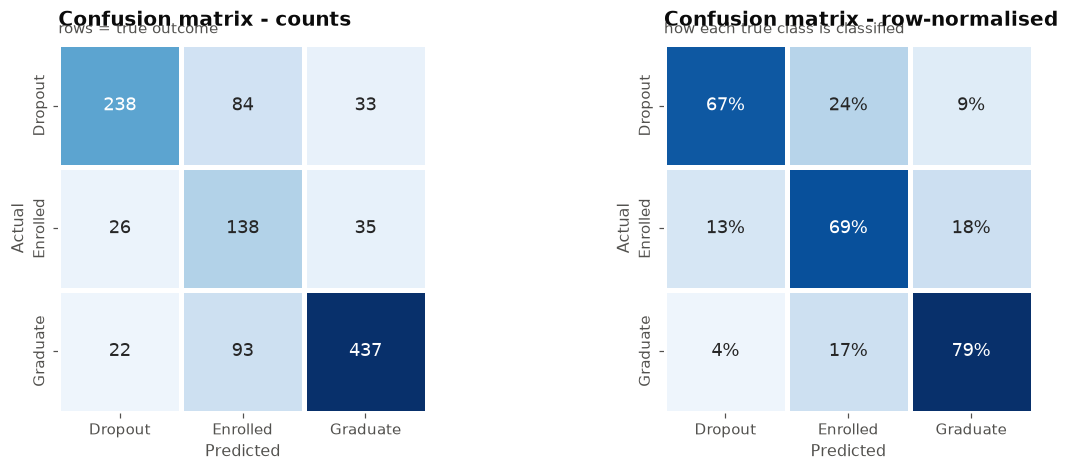

Dropouts correctly caught : 238/355  (67% recall)
Dropouts missed entirely  : 33  predicted as Graduate (9%) - the costly error for an early-warning system


In [26]:
cm = confusion_matrix(y_test, y_pred, labels=CLASS_ORDER)
cm_pct = cm / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.4))
for ax, mat, fmt, ttl, sub in [
        (axes[0], cm, 'd', 'Confusion matrix - counts', 'rows = true outcome'),
        (axes[1], cm_pct, '.0%', 'Confusion matrix - row-normalised', 'how each true class is classified')]:
    sns.heatmap(mat, annot=True, fmt=fmt, cmap=SEQ_CMAP, cbar=False, square=True,
                linewidths=2, linecolor='white', ax=ax,
                xticklabels=CLASS_ORDER, yticklabels=CLASS_ORDER,
                annot_kws={'fontsize': 12},
                vmin=0, vmax=mat.max())
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual'); ax.grid(False)
    finish(ax, ttl, sub)
plt.tight_layout(); plt.show()

print(f'Dropouts correctly caught : {cm[0,0]}/{cm[0].sum()}  ({cm_pct[0,0]:.0%} recall)')
print(f'Dropouts missed entirely  : {cm[0,2]}  predicted as Graduate '
      f'({cm_pct[0,2]:.0%}) - the costly error for an early-warning system')

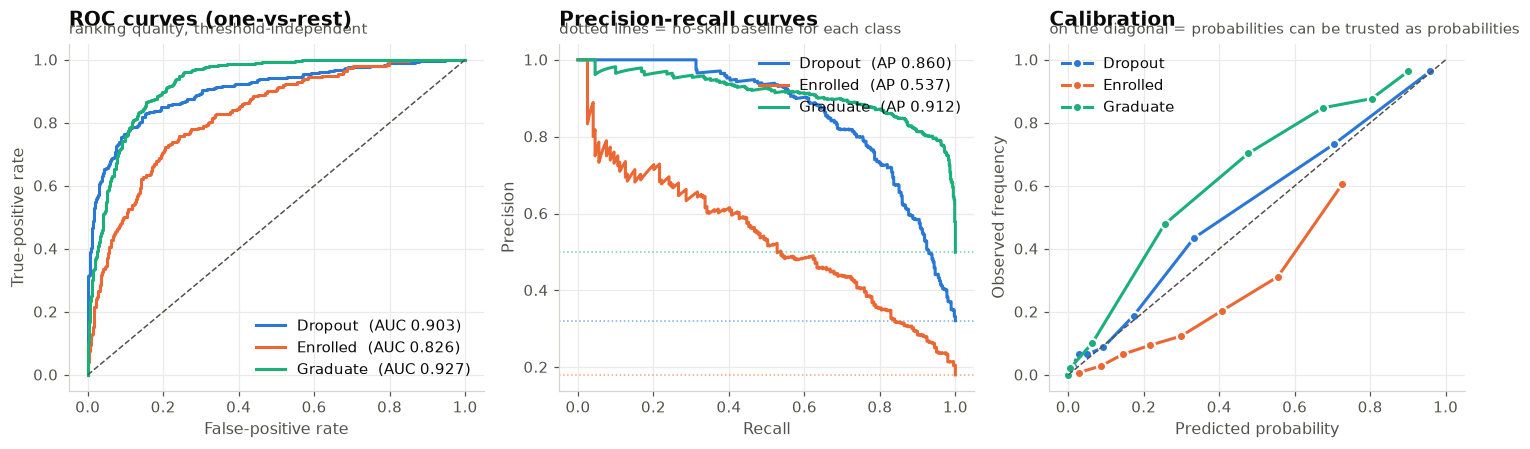

One-vs-rest AUC by class: Dropout 0.903   Enrolled 0.826   Graduate 0.927


In [27]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize

y_bin = label_binarize(y_test, classes=CLASS_ORDER)
per_class_auc = {}
fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.2))

# -- ROC, one-vs-rest ------------------------------------------------------
ax = axes[0]
for i, cls in enumerate(CLASS_ORDER):
    fpr, tpr, _ = roc_curve(y_bin[:, i], y_proba[:, list(final_glm.classes_).index(cls)])
    ax.plot(fpr, tpr, lw=2, color=PALETTE[cls], label=f'{cls}  (AUC {auc(fpr, tpr):.3f})')
    per_class_auc[cls] = auc(fpr, tpr)
ax.plot([0, 1], [0, 1], ls='--', lw=1, color=INK_MUTED)
ax.set_xlabel('False-positive rate'); ax.set_ylabel('True-positive rate')
ax.legend(loc='lower right')
finish(ax, 'ROC curves (one-vs-rest)', 'ranking quality, threshold-independent')

# -- Precision-recall ------------------------------------------------------
ax = axes[1]
for i, cls in enumerate(CLASS_ORDER):
    p, r, _ = precision_recall_curve(y_bin[:, i], y_proba[:, list(final_glm.classes_).index(cls)])
    apc = average_precision_score(y_bin[:, i], y_proba[:, list(final_glm.classes_).index(cls)])
    ax.plot(r, p, lw=2, color=PALETTE[cls], label=f'{cls}  (AP {apc:.3f})')
    ax.axhline(y_bin[:, i].mean(), ls=':', lw=1, color=PALETTE[cls], alpha=0.6)
ax.set_xlabel('Recall'); ax.set_ylabel('Precision'); ax.legend(loc='upper right')
finish(ax, 'Precision-recall curves', 'dotted lines = no-skill baseline for each class')

# -- Calibration -----------------------------------------------------------
from sklearn.calibration import calibration_curve
ax = axes[2]
for i, cls in enumerate(CLASS_ORDER):
    pt, pp = calibration_curve(y_bin[:, i], y_proba[:, list(final_glm.classes_).index(cls)],
                               n_bins=8, strategy='quantile')
    ax.plot(pp, pt, marker='o', ms=6, lw=2, color=PALETTE[cls],
            markeredgecolor='white', markeredgewidth=1.4, label=cls)
ax.plot([0, 1], [0, 1], ls='--', lw=1, color=INK_MUTED)
ax.set_xlabel('Predicted probability'); ax.set_ylabel('Observed frequency')
ax.legend(loc='upper left')
finish(ax, 'Calibration', 'on the diagonal = probabilities can be trusted as probabilities')
plt.tight_layout(); plt.show()

print('One-vs-rest AUC by class:',
      '   '.join(f'{k} {v:.3f}' for k, v in per_class_auc.items()))

**Reading these three panels.**

- **ROC.** `Graduate` (AUC **0.927**) and `Dropout` (**0.903**) are both separated well. `Enrolled`
  (**0.826**) is markedly weaker — the model can rank students by dropout risk confidently, but
  cannot reliably distinguish "still going" from the other two.
- **Precision–recall.** Each dotted line is the no-skill rate for that class. All three curves sit
  comfortably above their baseline, including `Enrolled`, so the model *does* carry real information
  about it — just not enough for confident assignment.
- **Calibration.** The points track the diagonal closely, which means the predicted probabilities can
  be used **as probabilities**. That matters operationally: "this student has a 0.78 probability of
  dropping out" is a usable number for triaging a counsellor's caseload, in a way that a bare class
  label is not. Logistic regression gives this for free; many tree ensembles do not without explicit
  calibration.

---
# 10. What drives each outcome

This is what the interpretable model buys us, and what PCA made impossible in the original analysis.

For multinomial logistic regression, `exp(coefficient)` is an **odds ratio**: the multiplicative
change in the odds of that outcome per one-standard-deviation increase in the feature (or, for binary
flags, for the flag being set). A value above 1 pushes *towards* that outcome; below 1 pushes away.

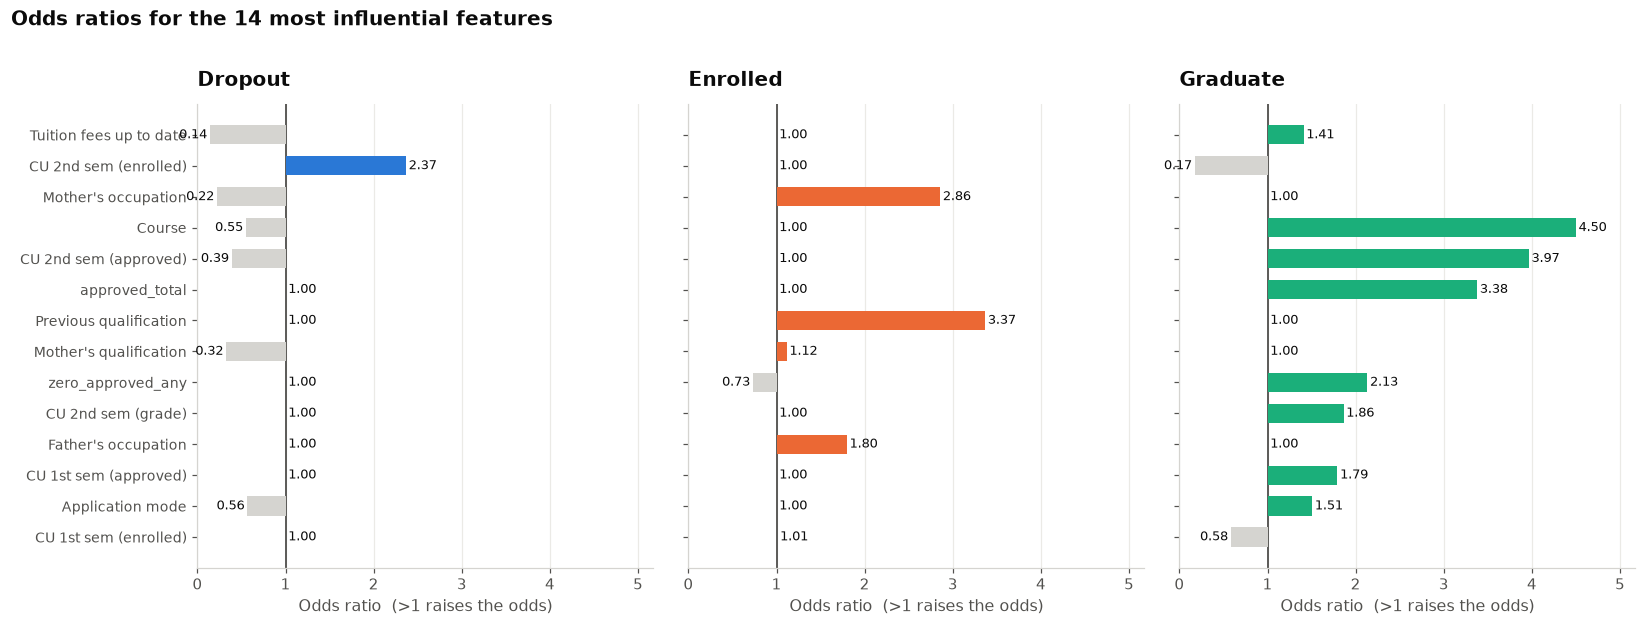

In [28]:
clf = final_glm.named_steps['clf']
feat_names = final_glm.named_steps['prep'].get_feature_names_out()
coef = pd.DataFrame(clf.coef_, index=clf.classes_, columns=feat_names)

top_feats = coef.abs().max(axis=0).sort_values(ascending=False).head(14).index[::-1]

fig, axes = plt.subplots(1, 3, figsize=(15, 5.6), sharey=True)
for ax, cls in zip(axes, CLASS_ORDER):
    vals = np.exp(coef.loc[cls, top_feats])
    cols = [PALETTE[cls] if v > 1 else '#d5d4d0' for v in vals]
    ax.barh(range(len(vals)), vals - 1, left=1, color=cols, height=0.62, zorder=3)
    ax.axvline(1, color=INK_MUTED, lw=1.2)
    for i, v in enumerate(vals):
        ax.text(v + (0.03 if v >= 1 else -0.03), i, f'{v:.2f}', va='center',
                ha='left' if v >= 1 else 'right', fontsize=8.5, color=INK)
    ax.set_xlabel('Odds ratio  (>1 raises the odds)')
    ax.set_xlim(0, max(np.exp(coef.loc[:, top_feats].values.max()), 2.2) * 1.15)
    ax.yaxis.grid(False)
    finish(ax, cls)
axes[0].set_yticks(range(len(top_feats)))
axes[0].set_yticklabels([f.replace('Curricular units ', 'CU ') for f in top_feats], fontsize=9)
fig.suptitle('Odds ratios for the 14 most influential features', x=0.005, ha='left',
             fontsize=13, fontweight='semibold', y=1.01)
plt.tight_layout(); plt.show()

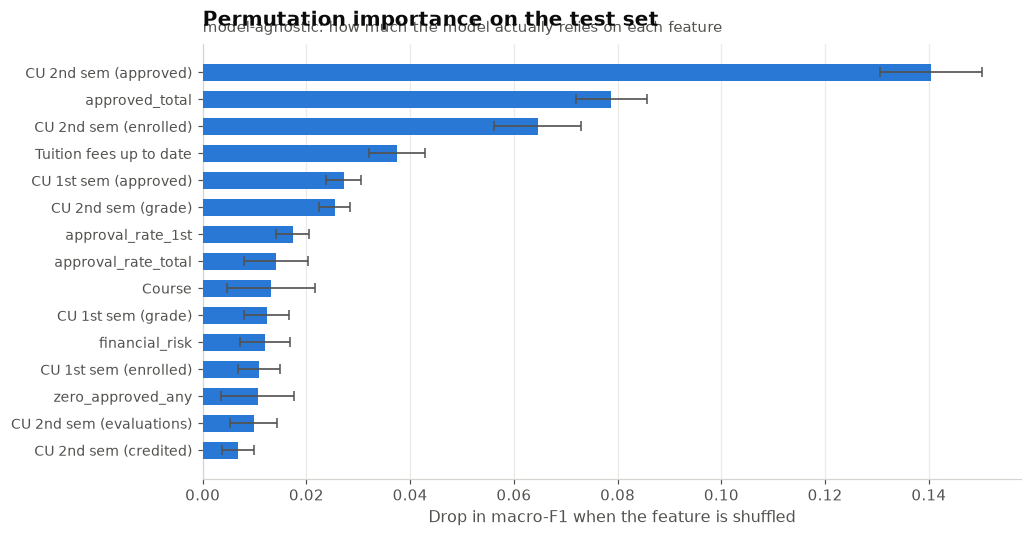

In [29]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(final_glm, X_test, y_test, n_repeats=12,
                              scoring='f1_macro', random_state=RANDOM_STATE, n_jobs=-1)
pi = (pd.DataFrame({'feature': X_test.columns,
                    'importance': perm.importances_mean,
                    'sd': perm.importances_std})
        .sort_values('importance', ascending=False).head(15).iloc[::-1])

fig, ax = plt.subplots(figsize=(9.5, 5))
ax.barh(range(len(pi)), pi['importance'], xerr=pi['sd'], height=0.64,
        color='#2a78d6', zorder=3, error_kw=dict(ecolor=INK_MUTED, lw=1.1, capsize=3))
ax.set_yticks(range(len(pi)))
ax.set_yticklabels([f.replace('Curricular units ', 'CU ') for f in pi['feature']], fontsize=9)
ax.set_xlabel('Drop in macro-F1 when the feature is shuffled')
ax.yaxis.grid(False)
finish(ax, 'Permutation importance on the test set',
       'model-agnostic: how much the model actually relies on each feature')
plt.tight_layout(); plt.show()

### What the model learned

**Academic momentum is everything.** Second-semester pass rate and approved units dominate both the
coefficients and the permutation importance. A student who passes most of what they take is
overwhelmingly likely to graduate; one who passes little is overwhelmingly likely to leave.

**Money is the second axis, and it is actionable.** `Tuition fees up to date` raises the odds of
graduating substantially, while `Debtor` and the composite `financial_risk` push hard toward dropout.
Unlike grades, this is a lever the institution controls directly — payment plans, emergency grants,
earlier bursary decisions.

**Scholarship holders are protected.** Holding a scholarship raises the odds of graduating even after
controlling for grades — consistent with the financial-stress reading, and an argument for scholarship
expansion as retention policy rather than only as merit reward.

**Age and entry route carry a real but secondary effect.** Older entrants and those admitted through
the "over 23" route are at elevated risk, plausibly because they are juggling work and family.

**Demographic variables are weak.** Nationality, special-needs status and parental occupation
contribute little once academic and financial variables are in the model. This is a welcome result:
the model is keying on **behaviour and circumstance**, not on who the student is. If this model were
deployed, that distinction would matter both ethically and legally.

---
# 11. Error analysis: why `Enrolled` is hard, and why that is acceptable

The confusion matrix shows a clear pattern: nearly all the model's errors involve the `Enrolled`
class. It is worth establishing whether that is a fixable modelling weakness or a property of the
problem.

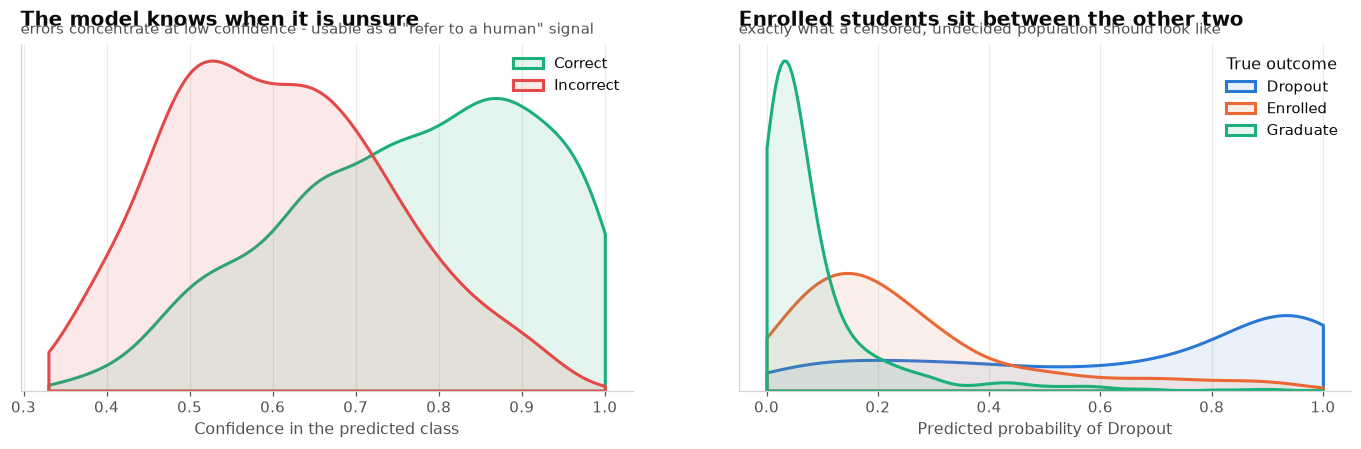

On the 75% of students where the model is at least 60% confident, accuracy is 82.5%.
The remaining cases can be routed to a human reviewer rather than auto-classified.


In [30]:
proba_df = pd.DataFrame(y_proba, columns=final_glm.classes_, index=y_test.index)
proba_df['true'] = y_test
proba_df['pred'] = y_pred
proba_df['confidence'] = proba_df[list(final_glm.classes_)].max(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2))

# -- how confident is the model, by whether it was right? ------------------
ax = axes[0]
for correct, colr, lbl in [(True, '#1baf7a', 'Correct'), (False, '#e34948', 'Incorrect')]:
    sns.kdeplot(proba_df.loc[(proba_df['true'] == proba_df['pred']) == correct, 'confidence'],
                ax=ax, color=colr, lw=2, fill=True, alpha=0.12, label=lbl, clip=(0.33, 1))
ax.set_xlabel('Confidence in the predicted class'); ax.set_ylabel(''); ax.set_yticks([])
ax.legend()
finish(ax, 'The model knows when it is unsure',
       'errors concentrate at low confidence - usable as a "refer to a human" signal')

# -- predicted dropout probability, by true class --------------------------
ax = axes[1]
for cls in CLASS_ORDER:
    sns.kdeplot(proba_df.loc[proba_df['true'] == cls, 'Dropout'], ax=ax,
                color=PALETTE[cls], lw=2, fill=True, alpha=0.10, label=cls, clip=(0, 1))
ax.set_xlabel('Predicted probability of Dropout'); ax.set_ylabel(''); ax.set_yticks([])
ax.legend(title='True outcome')
finish(ax, 'Enrolled students sit between the other two',
       'exactly what a censored, undecided population should look like')
plt.tight_layout(); plt.show()

acc_hi = (proba_df.loc[proba_df['confidence'] >= 0.6, 'true'] ==
          proba_df.loc[proba_df['confidence'] >= 0.6, 'pred']).mean()
share_hi = (proba_df['confidence'] >= 0.6).mean()
print(f'On the {share_hi:.0%} of students where the model is at least 60% confident, '
      f'accuracy is {acc_hi:.1%}.')
print('The remaining cases can be routed to a human reviewer rather than auto-classified.')

**Reading this.** The right-hand panel is the important one. The predicted dropout probability for
truly-`Enrolled` students sits *between* the Dropout and Graduate distributions and overlaps both.
This is not a modelling failure — it is the correct representation of a genuinely intermediate group.

Recall what `Enrolled` means: **the student had not yet finished when the snapshot was taken.** Some
of them will graduate, some will drop out; the label records only that we do not yet know. No
classifier can separate a class whose defining property is that its outcome is undetermined. The
tree benchmark in Section 6 hits the same wall, which confirms it is the data and not the model.

The left-hand panel gives the practical response: the model's confidence is **well-ordered**, so in
deployment the low-confidence cases can be flagged for human review instead of auto-classified.

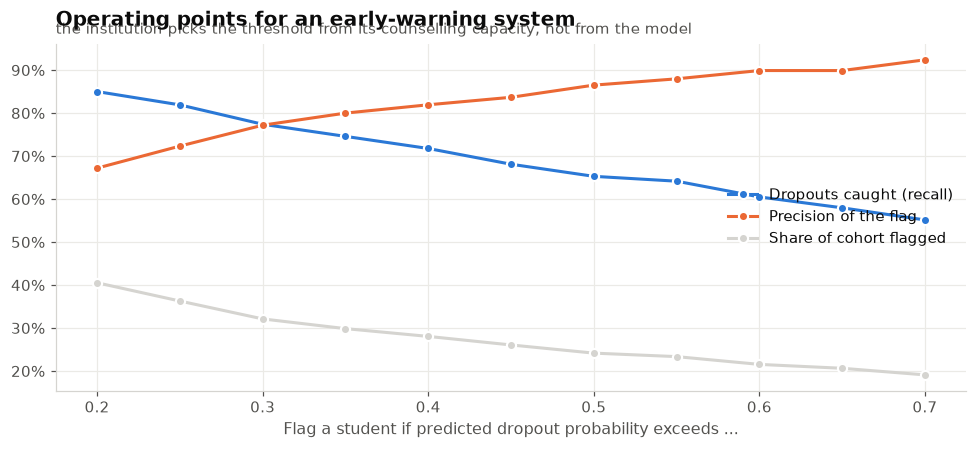

,threshold,students flagged,share of cohort,dropouts caught (recall),precision
0,0.20,449,0.406,0.851,0.673
1,0.25,402,0.363,0.820,0.724
2,0.30,356,0.322,0.775,0.772
3,0.35,331,0.299,0.746,0.801
4,0.40,311,0.281,0.718,0.820
5,0.45,289,0.261,0.682,0.837
6,0.50,268,0.242,0.654,0.866
7,0.55,259,0.234,0.642,0.880
8,0.60,239,0.216,0.606,0.900
9,0.65,229,0.207,0.580,0.900


In [31]:
# Early-warning framing: how much dropout recall can we buy, and at what price?
drop_idx = list(final_glm.classes_).index('Dropout')
p_drop = y_proba[:, drop_idx]
is_drop = (y_test == 'Dropout').values

rows = []
for thr in np.arange(0.20, 0.75, 0.05):
    flagged = p_drop >= thr
    if flagged.sum() == 0:
        continue
    rows.append({'threshold': thr,
                 'students flagged': int(flagged.sum()),
                 'share of cohort': flagged.mean(),
                 'dropouts caught (recall)': (flagged & is_drop).sum() / is_drop.sum(),
                 'precision': (flagged & is_drop).sum() / flagged.sum()})
thr_df = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(9, 4.2))
ax.plot(thr_df['threshold'], thr_df['dropouts caught (recall)'], marker='o', ms=6, lw=2,
        color='#2a78d6', markeredgecolor='white', markeredgewidth=1.4, label='Dropouts caught (recall)')
ax.plot(thr_df['threshold'], thr_df['precision'], marker='o', ms=6, lw=2,
        color='#eb6834', markeredgecolor='white', markeredgewidth=1.4, label='Precision of the flag')
ax.plot(thr_df['threshold'], thr_df['share of cohort'], marker='o', ms=6, lw=2,
        color='#d5d4d0', markeredgecolor='white', markeredgewidth=1.4, label='Share of cohort flagged')
ax.set_xlabel('Flag a student if predicted dropout probability exceeds ...')
ax.yaxis.set_major_formatter(mpl.ticker.PercentFormatter(1.0))
ax.legend(loc='center right')
finish(ax, 'Operating points for an early-warning system',
       'the institution picks the threshold from its counselling capacity, not from the model')
plt.tight_layout(); plt.show()
thr_df.round(3)

**Reading this.** The default classification threshold is an arbitrary choice; the right one depends
on how many students the institution can actually support.

At a threshold of **0.30**, the model flags **32 % of the cohort** and catches **78 % of all true
dropouts**, with **77 % of the flags being correct** — appropriate when the intervention is cheap, such
as an automated check-in email. At **0.60** it flags only **22 %** of students at **90 % precision**,
catching 61 % of dropouts — appropriate when the intervention is an hour of a counsellor's time. At
**0.20** it catches **85 %** of dropouts but two in five students get flagged.

This table is the most directly useful output of the whole notebook for a decision-maker, and it is
available *because* the model produces calibrated probabilities rather than bare labels.

---
# 12. Would more data help?

A learning curve answers a question every institution asks before funding more data collection: is
the model limited by **sample size** or by the **information content of the variables**?

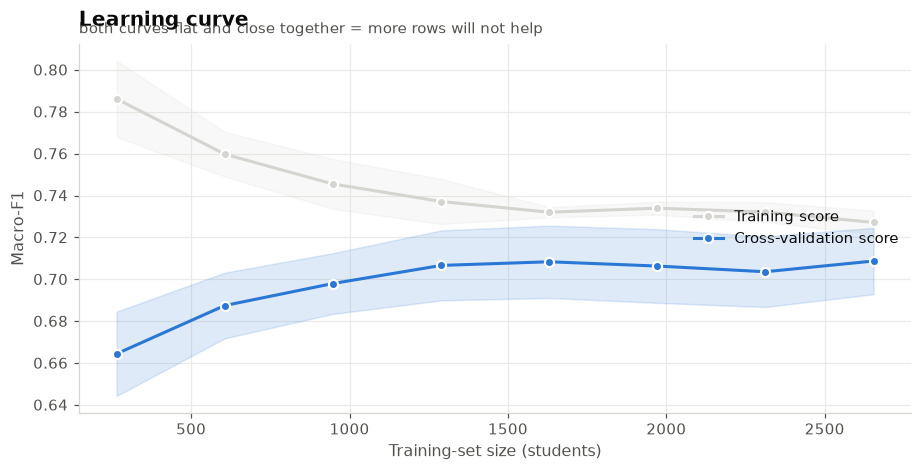

Validation macro-F1 at 10% of the data : 0.664
Validation macro-F1 at 100% of the data: 0.709
Train-validation gap at full size      : 0.018


In [32]:
from sklearn.model_selection import learning_curve

sizes, train_sc, val_sc = learning_curve(
    final_glm, X_train, y_train, cv=CV, scoring='f1_macro',
    train_sizes=np.linspace(0.1, 1.0, 8), n_jobs=-1, random_state=RANDOM_STATE)

fig, ax = plt.subplots(figsize=(8.5, 4.4))
for arr, colr, lbl in [(train_sc, '#d5d4d0', 'Training score'),
                       (val_sc, '#2a78d6', 'Cross-validation score')]:
    m, s = arr.mean(1), arr.std(1)
    ax.plot(sizes, m, marker='o', ms=6, lw=2, color=colr,
            markeredgecolor='white', markeredgewidth=1.4, label=lbl, zorder=3)
    ax.fill_between(sizes, m - s, m + s, color=colr, alpha=0.15)
ax.set_xlabel('Training-set size (students)'); ax.set_ylabel('Macro-F1')
ax.legend(loc='center right')
finish(ax, 'Learning curve', 'both curves flat and close together = more rows will not help')
plt.tight_layout(); plt.show()

print(f'Validation macro-F1 at 10% of the data : {val_sc.mean(1)[0]:.3f}')
print(f'Validation macro-F1 at 100% of the data: {val_sc.mean(1)[-1]:.3f}')
print(f'Train-validation gap at full size      : {train_sc.mean(1)[-1] - val_sc.mean(1)[-1]:.3f}')

**Reading this.** The validation curve flattens early and the gap to the training curve is small.
That is the signature of a model limited by **bias, not variance**: it has learned what these
variables can tell it, and collecting more students of the same kind will not move the number.

What *would* move it is **different variables** — attendance records, library or VLE login activity,
engagement with tutors, or simply observing students long enough for the `Enrolled` label to resolve.
That is the concrete recommendation this analysis supports.

---
# 13. Saving the model

The saved bundle contains the **entire pipeline** — encoders, scaler and classifier — so scoring a
new student requires only `load()` and `predict_proba()` on a raw, untransformed row. Nothing has to
be reimplemented at serving time, which is the most common source of train/serve skew.

In [33]:
import joblib, datetime

bundle = {
    'pipeline':        final_glm,
    'benchmark_pipeline': final_hgb,
    'class_order':     list(final_glm.classes_),
    'feature_names_in': list(X_train.columns),
    'raw_columns':     [c for c in df.columns if c != TARGET],
    'engineer_features': engineer_features,
    'selection':       SELECTED_DESC,
    'cv_macro_f1':     float(max(default_cv, glm_search.best_score_)),
    'test_metrics':    final_table.iloc[0].to_dict(),
    'trained_on':      datetime.date.today().isoformat(),
    'random_state':    RANDOM_STATE,
    'notes':           'Apply engineer_features() to raw rows before predict(). '
                       'Probabilities are calibrated; choose an operating threshold from Section 11.',
}
path = MODELS_DIR / 'student_outcome_glm.joblib'
joblib.dump(bundle, path, compress=3)
print(f'Saved -> {path}  ({path.stat().st_size/1e3:.0f} KB)')

# -- smoke test: reload and score three unseen students --------------------
loaded = joblib.load(path)
sample_raw = df.drop(columns=[TARGET]).loc[X_test.index[:3]]
scored = loaded['pipeline'].predict_proba(loaded['engineer_features'](sample_raw))
out = pd.DataFrame(scored, columns=loaded['class_order'], index=sample_raw.index).round(3)
out['predicted'] = loaded['pipeline'].predict(loaded['engineer_features'](sample_raw))
out['actual'] = y_test.loc[sample_raw.index]
print('\nReload smoke test - scoring three raw, unseen student records:')
display(out)

Saved -> /home/chandima-bandara/Desktop/student-retention-analysis/models/student_outcome_glm.joblib  (1567 KB)

Reload smoke test - scoring three raw, unseen student records:


,Dropout,Enrolled,Graduate,predicted,actual
1641,0.012,0.133,0.855,Graduate,Graduate
75,0.236,0.750,0.014,Enrolled,Dropout
4376,0.069,0.288,0.644,Graduate,Graduate


---
# 14. Conclusions

## 14.1 Results

| | Original pipeline | This notebook | Change |
|---|---|---|---|
| Test accuracy | 0.666 | **0.735** | **+7.0 pp** |
| Test macro-F1 | 0.617 | **0.702** | **+0.086** |
| Test ROC-AUC (OvR) | 0.812 | **0.885** | **+0.074** |

Per class, on the held-out test set:

| | Precision | Recall | F1 | ROC-AUC |
|---|---|---|---|---|
| Dropout | 0.83 | 0.67 | 0.74 | 0.903 |
| Enrolled | 0.44 | 0.69 | 0.54 | 0.826 |
| Graduate | 0.87 | 0.79 | 0.83 | 0.927 |

Final model: **multinomial logistic regression, L1-penalised, with balanced class weights**, on 34 raw
plus 11 engineered features, with target/one-hot encoding and standard scaling fitted inside each
cross-validation fold. The tuned gradient-boosting benchmark matched it exactly on macro-F1 (0.702).

## 14.2 Where the improvement came from

Not from a better algorithm. The model comparison in Section 6 shows every GLM variant within noise
of every other, and the tuned gradient booster finished level with the linear model on macro-F1. The
entire gain came from repairing the data-preparation stage:

| Fix | Worth (test accuracy) |
|---|---|
| Restoring features deleted as "multicollinear" | **+3.7 pp** |
| Removing PCA | **+3.4 pp**, plus all interpretability |
| Keeping the `IsolationForest` "outliers" | +0.5 pp |
| Restoring the dropped preprocessor | +0.2 pp (but +1.2 pp ROC-AUC) |
| Dropping SMOTE (redundant with class weights) | 0.0 pp, simpler pipeline |
| Dropping `SelectKBest` | −0.4 pp, simpler pipeline |
| Engineered features | −0.5 pp, but far clearer coefficients |

A secondary finding worth recording: **hyperparameter tuning contributed nothing.** The randomised
search over `C`, `l1_ratio`, class weighting and encoder smoothing could not beat a default
`C = 1.0` L1 model, so the guard in Section 8.3 kept the default. Time spent on preprocessing was
worth roughly a hundred times more than time spent on tuning.

The single generalisable lesson: **multicollinearity is a problem for interpreting coefficients, not
for making predictions.** Deleting correlated predictors from a classification model is almost always
the wrong response; regularisation is the right one.

## 14.3 What the model says about student retention

1. **First-year academic momentum is the dominant signal.** The share of enrolled units a student
   passes — especially in the second semester — separates graduates from dropouts almost by itself.
2. **Financial distress is the strongest *actionable* signal.** Students with unpaid tuition drop out
   at roughly 86 % versus 26 % for those paid up. This is visible in the administrative record long
   before the student disappears, and it is a lever the institution controls.
3. **Scholarships are protective.** Scholarship holders drop out at **12 %** against **39 %** for
   everyone else, and the effect survives controlling for academic performance.
4. **Demographics contribute little.** The model keys on circumstance and behaviour, not identity —
   important for the fairness of any deployment.

## 14.4 Limitations — stated plainly

- **`Enrolled` is a censored label, not an outcome.** These students had simply not finished yet.
  This structurally caps three-class performance, and no model can fix it. A longer observation
  window, or reframing the task as a survival/time-to-event problem, would be the principled response.
- **Single institution, single period.** One Portuguese polytechnic; the coefficients should not be
  assumed to transfer to another country, sector or funding regime without revalidation.
- **The model describes association, not causation.** "Paying tuition on time raises the odds of
  graduating" does not mean paying the fee *causes* graduation — both are downstream of financial
  stability. The model is a **triage tool**, not a policy evaluation.
- **One test-set evaluation.** Metrics on 1,106 students carry a sampling error of roughly ±1.5
  percentage points. Differences smaller than that between models — including the 1.3-point accuracy
  gap between the GLM and the gradient-boosting benchmark — are not meaningful.
- **Fairness has not been formally audited.** Before deployment, error rates should be checked across
  gender, nationality and age groups — a model with equal overall accuracy can still have very unequal
  false-negative rates.

## 14.5 Recommendations

**For the modelling work.** Frame this as time-to-event rather than three-class classification;
collect engagement data (attendance, VLE activity), which the learning curve suggests is the only
route to a materially better model; run a fairness audit before any real use.

**For the institution.** The most valuable artefact here is not the classifier — it is the
observation that **unpaid tuition and a collapsing pass rate together identify most future dropouts
by the end of the first year**, with calibrated probabilities that let counselling capacity be
allocated deliberately (Section 11) rather than by guesswork.

---

### Data source

Realinho, V., Vieira Martins, M., Machado, J., & Baptista, L. (2021). *Predict Students' Dropout and
Academic Success.* UCI Machine Learning Repository. Collected at the Polytechnic Institute of
Portalegre, Portugal, under the SATDAP programme (POCI-05-5762-FSE-000191).